In [1]:
# TODO: Import all required libraries
# sympy, numpy, matplotlib, scipy.optimize, scipy.special

# TODO: Import all required libraries here

import sympy as sp
from sympy import symbols, Function, exp, diff, simplify, expand, sqrt, Rational, LambertW, pprint
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, newton
from scipy.special import lambertw

sp.init_printing()
plt.rcParams['figure.figsize'] = (10, 6)

plt.style.use('seaborn-v0_8-darkgrid')


from IPython.display import HTML
from IPython.display import display
display(HTML("<style>.MathJax { font-size: 150% !important; }</style>"))



# $\Omega_x$ research  
we first define the main symbols/parameters

In [2]:
z,a, b, rho_x= symbols(r'z a b \rho_{x}(z)')
H, H_0, Omega_m, Omega_r, Omega_lambda, z_c, sigma_z = symbols(r'H H_0 \Omega_{m} \Omega_{r} \Omega_{\Lambda} z_c \sigma_z ', real=True, positive= True)

Then define the $\rho_x$ and $\Omega_x$ equations

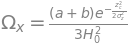

In [3]:
rhox_exp = (a+(b*(1+z))) * sp.exp(-(z-z_c)**2/(2*(sigma_z)**2))                         

rhox_eqn = sp.Eq(rho_x, rhox_exp)

display(rhox_eqn)

rhox_zero_sym, Omega_x = symbols(r'\rho_{x}(z=0) \Omega_x')

Omegax_exp = rhox_zero_sym/(3*H_0**2)

rhox_zero = sp.Eq(rhox_zero_sym, rhox_eqn.rhs.subs(z,0))
display(rhox_zero)


Omegax_exp = Omegax_exp.subs(rhox_zero_sym, rhox_zero.rhs)


Omegax_eqn = sp.Eq(Omega_x, Omegax_exp)

display(Omegax_eqn)

Now onto the modified friedmann equation

In [4]:
Hz, Wz = symbols('H(z) \mathcal{W}(z)')
Friedmann_exp = H_0**2 * (Omega_m *(1+z)**3 + Omega_r* (1+z)**4  + Omega_lambda + Omega_x * Wz )

Friedmann_eqn = sp.Eq(Hz**2, Friedmann_exp)

display(Friedmann_eqn)


Now to find $\mathcal{W}(z)$ using $$ H(z)^2 = H_0^2 \sum_i \Omega_i \cdot f_{i}(z) $$ & $$ f_{i}(z) = \dfrac{\rho_i(z)}{\rho_i(z=0)}$$
Therefore,
$$ \mathcal{W}(z) = \dfrac{\rho_x(z)}{\rho_x(z=0)}$$

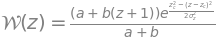

In [5]:
Wz_exp = rhox_exp/(rhox_zero.rhs)

Wz_exp = simplify(Wz_exp)

Wz_eqn = sp.Eq(Wz,Wz_exp)

display(Wz_eqn)


Before finding the final Friedmann equation form we should deduce the equation of state function for $\Omega_x$ and find $\omega_x, p_x$

$\because \dot{\rho_{DE}} + 3H(\rho_{DE}+P_{DE}) = 0$
by using the chain rule on $\rho_{DE}$ we get
$$\omega_x(z) = \dfrac{(1+z)}{\rho_x} \frac{d\rho_x}{dz}-1 $$

one can either plug the original $\rho_x$ here or use the other method of

In [6]:
# 1. Get the expression for rhox_zero_sym: [Omega_x * 3 * H_0**2]

Omegax_eqn_2 = sp.Eq(Omega_x, rhox_zero.lhs/(3*H_0))

rhox_zero_val = sp.solve(Omegax_eqn_2, rhox_zero_sym)[0]

# 2. Use your W(z) = rho_x / rhox_zero_sym equation
Wz_eqn_2 = sp.Eq(Wz, rho_x / rhox_zero_sym)

# 3. Isolate rho_x
rhox_isolated = sp.solve(Wz_eqn_2, rho_x)[0]

final_rhox_expr = rhox_isolated.subs(rhox_zero_sym, rhox_zero_val)


final_rhox_eqn = sp.Eq(rho_x, final_rhox_expr)

display(final_rhox_eqn)


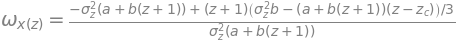

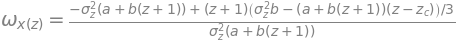

In [7]:
omega_x = symbols(r'\omega_x(z)')
omega_x


drhox_dz = sp.Derivative(rho_x,z) 
omega_x_eqn = sp.Eq(omega_x, ((1+z)/(3*rho_x))*(drhox_dz)-1)

display(omega_x_eqn)

final_rhox_expr = final_rhox_expr.subs(Wz, Wz_exp)

final_omega_eqn = omega_x_eqn.subs({
   drhox_dz: sp.diff(final_rhox_expr, z),
    rho_x: final_rhox_expr,
})

final_omega_eqn = sp.simplify(final_omega_eqn)

display(final_omega_eqn)

## OR
dW_dz = sp.Derivative(Wz_exp,z)
omega_x_eqn_2 = sp.Eq(omega_x, ((1+z)/(3*Wz))*(dW_dz)-1)
omega_x_eqn_final = omega_x_eqn_2.subs({dW_dz:dW_dz.doit(), Wz:Wz_exp})

omega_x_eqn_final = simplify(omega_x_eqn_final)

display(omega_x_eqn_final)


Or the much cleaner 
$$\omega_x(z) = \dfrac{(1+z)}{3} \left[\dfrac{z_c-z}{\sigma_z^2}+\dfrac{b}{a+b(1+z)}\right]-1$$
now onto $P_x$, which is just $P_x = \omega_x \cdot \rho_x$

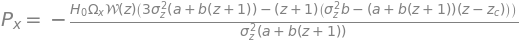

In [8]:
P_x = symbols('P_x')
P_x_eqn = sp.Eq(P_x,omega_x_eqn_final.rhs * final_rhox_eqn.rhs)

P_x_eqn = simplify(P_x_eqn)

P_x_eqn

... or the much cleaner $$ P_x = \Omega_x \cdot 3H_0^2 \cdot \mathcal{W}(z)\cdot \left\{\dfrac{(1+z)}{3} \left[\dfrac{z_c-z}{\sigma_z^2}+\dfrac{b}{a+b(1+z)}\right]-1\right\}$$

Therefore the final form of the modified Friedmann equation becomes:

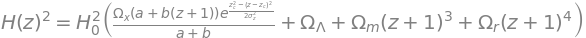

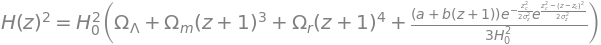

In [9]:
final_Friedmann = sp.Eq(Hz**2, Friedmann_exp.subs(Wz,Wz_exp))
display(final_Friedmann)

#final_Friedmann = simplify(final_Friedmann)

final_Friedmann = sp.Eq(Hz**2, final_Friedmann.rhs.subs(Omega_x,Omegax_exp))   #Rewrite using Omega_x, b, isolate a
display(final_Friedmann)

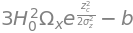

In [10]:
a_exp = sp.solve(Omegax_eqn, a)
a_exp = a_exp[0]

final_Friedmann_final = sp.Eq(Hz**2, final_Friedmann.rhs.subs(a, a_exp))   #Rewrite using Omega_x, b, isolate a

#final_Friedmann = simplify(final_Friedmann)

final_Friedmann_final
display(a_exp)

### Defining the Peak Fractional Energy ($\tilde{f}_x$)

* **What it means:** $\tilde{f}_x$ represents the **maximum fractional energy contribution** of the modified gravity component. Because the exotic energy is highly localized at high redshift, its present-day density ($\Omega_x$) is infinitesimally small. $\tilde{f}_x$ translates this into a physically meaningful parameter, telling us exactly what percentage of the universe's total energy budget the modification accounts for at its peak.
* **Mathematical Definition:** It is defined as the absolute ratio of the exotic energy density to the standard $\Lambda$CDM baseline energy density, evaluated strictly at the transition redshift $z_c$: $$\tilde{f}_x = \frac{|\Omega_x \mathcal{W}(z_c)|}{E_{\Lambda CDM}^2(z_c)}$$
* **SymPy Implementation:** To derive this symbolically, we evaluate the isolated window function $\mathcal{W}(z)$ at $z = z_c$, multiply by the amplitude $\Omega_x$, and divide by the standard Friedmann expansion rate $E^2(z_c)$ (which is the full Friedmann equation evaluated with $\Omega_x = 0$).

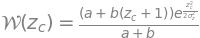

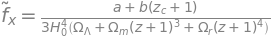

In [11]:
Wz_peak, fx= symbols(r'\mathcal{W}(z_c) \tilde{f}_x')

E2_LCDM_zc = symbols('E_{LCDM}^2(z_{c})')

Wz_peak_eq = sp.Eq(Wz_peak, Wz_eqn.subs(z, z_c).rhs)

display(Wz_peak_eq)

Wz_eq_final = sp.Eq(Wz, Wz_exp.subs(a, a_exp)) #IN TERMS OF b, Omega_x

fx_peak = sp.Eq(fx, (Omega_x * Wz_peak_eq.lhs) /E2_LCDM_zc)

fx_peak_eqn = fx_peak.subs({
    Omega_x: Omegax_exp,
    Wz_peak: Wz_peak_eq.rhs,
    E2_LCDM_zc : Friedmann_eqn.rhs.subs(Omega_x, 0)
})

display(fx_peak_eqn)

Now to see how the Friedmann equation changes with different constants. Making it in terms of b, Omega_x ONLY.

In [12]:
# # plotting code cell 1 (with a)

# calc_Hz2 = sp.lambdify((z, H_0, Omega_r, Omega_m, Omega_lambda, Omega_x, a, b, z_c, sigma_z),final_Friedmann.rhs,'numpy')


# import matplotlib.gridspec as gridspec

# # ── GLOBAL COSMOLOGY & MODEL PARAMETERS ──
# # Change these here, and they will automatically update everywhere in the plot and math!
# H0_VAL = 70
# OM_VAL = 0.3
# OR_VAL = 9e-5
# OL_VAL = 0.7
# A_VAL  = 0.5
# B_VAL  = 0.5

# # Expanded vibrant palette for dark backgrounds
# COLORS = [
#     '#38bdf8', '#f472b6', '#34d399', '#fbbf24', '#a78bfa',
#     '#ef4444', '#8b5cf6', '#06b6d4', '#f97316', '#10b981',
#     '#ec4899', '#eab308', '#6366f1', '#14b8a6', '#f43f5e'
# ]

# # 1. Wrapper function to calculate E(z) cleanly
# def get_Ez(z, Omega_x, z_c, sigma_z, a=A_VAL, b=B_VAL, H0=H0_VAL, Omega_m=OM_VAL, Omega_r=OR_VAL, Omega_lambda=OL_VAL):
#     # Reminder of calc_Hz2 order: (z, H_0, Omega_r, Omega_m, Omega_lambda, Omega_x, a, b, z_c, sigma_z)
#     Hz2 = calc_Hz2(z, H0, Omega_r, Omega_m, Omega_lambda, Omega_x, a, b, z_c, sigma_z)
#     Ez = np.sqrt(Hz2) / H0
#     return Ez

# # ── Style ──────────────────────────────────────────────────────────────────
# plt.style.use('dark_background')

# def get_f_peak(Omega_x, z_c, sigma_z, a=A_VAL, b=B_VAL, H0=H0_VAL, Omega_m=OM_VAL, Omega_r=OR_VAL, Omega_lambda=OL_VAL):
#     """Compute the peak fractional contribution of the exotic component."""
#     # W at z = z_c: Gaussian = 1, linear factor evaluated at peak
#     Wz_peak = (a + b*(1 + z_c)) / (a + b) * np.exp(z_c**2 / (2*sigma_z**2))
    
#     # E(z_c) from your existing function
#     Ez_c = get_Ez(z_c, Omega_x, z_c, sigma_z, a=a, b=b, H0=H0, Omega_m=Omega_m, Omega_r=Omega_r, Omega_lambda=Omega_lambda)
    
#     return abs(Omega_x * Wz_peak) / Ez_c**2

# z_vals   = np.logspace(-1, np.log10(125), 3000)

# # Calculate LCDM baseline using the global parameters
# Ez_lcdm  = get_Ez(z_vals, Omega_x=0, z_c=0, sigma_z=1e-9, a=A_VAL, b=B_VAL)

# sweep_configs = [
#     {
#         "title"    : r"Sweep 1 — Amplitude $(\Omega_x)$",
#         "sweep_key": "Omega_x",  
#         "label_key": r"$\Omega_x = {}$",
#         "params"   : [
#             dict(Omega_x=-0.001, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.01, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.02, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.03, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.0325, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.04, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.05, z_c=20, sigma_z=5)
#         ],
#     },
#     {
#         "title"    : r"Sweep 2 — Location $(z_c)$",
#         "sweep_key": "z_c",      
#         "label_key": r"$z_c = {}$",
#         "params"   : [
#             dict(Omega_x=-0.02, z_c=10,  sigma_z=5),
#             dict(Omega_x=-0.02, z_c=20,  sigma_z=5),
#             dict(Omega_x=-0.02, z_c=35,  sigma_z=5),
#             dict(Omega_x=-0.02, z_c=50,  sigma_z=5),
#         ],
#     },
#     {
#         "title"    : r"Sweep 3 — Width $(\sigma_z)$",
#         "sweep_key": "sigma_z",  
#         "label_key": r"$\sigma_z = {}$",
#         "params"   : [
#             dict(Omega_x=-0.02, z_c=20, sigma_z=2),
#             dict(Omega_x=-0.02, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.02, z_c=20, sigma_z=10),
#             dict(Omega_x=-0.02, z_c=20, sigma_z=15),
#         ],
#     },
# ]

# # ── HELPER: Proper LaTeX Scientific Notation ──
# def to_tex(val):
#     """Converts a float to a clean LaTeX scientific notation string."""
#     if val == 0: 
#         return "0"
#     exp = int(np.floor(np.log10(abs(val))))
#     base = val / 10**exp
#     base = round(base, 3) 
#     if base.is_integer(): 
#         base = int(base)
        
#     if base == 1: 
#         return f"10^{{{exp}}}"
#     elif base == -1: 
#         return f"-10^{{{exp}}}"
#     else: 
#         return f"{base} \\times 10^{{{exp}}}"

# # ── Figure: 2 rows × 3 cols ────────────────────────────────────────────────
# fig = plt.figure(figsize=(20, 10))
# gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3, left=0.08)

# for col, cfg in enumerate(sweep_configs):  # remember! enumerate gives index, object, then cfg = dict at idx col

#     ax_ratio = fig.add_subplot(gs[0, col])   # top row
#     ax_raw   = fig.add_subplot(gs[1, col])   # bottom row

#     # ── shared ΛCDM reference ──
#     ax_ratio.plot(z_vals, np.ones_like(z_vals), color='#9ca3af', lw=2, ls='-', label=r'$\Lambda$CDM', zorder=1)
#     ax_raw.plot(z_vals, Ez_lcdm, color='#9ca3af', lw=2, ls='-', label=r'$\Lambda$CDM', zorder=1)

#     # Loop through however many models you put in the dict
#     for i, params in enumerate(cfg["params"]):
        
#         lv = params[cfg["sweep_key"]]
        
#         Ez_m   = get_Ez(z_vals, **params)
#         ratio  = Ez_m / Ez_lcdm
#         f_peak = get_f_peak(**params)
#         ox_val = params["Omega_x"]
        
#         # ── THE NEW LABEL LOGIC ──
#         sweep_lbl = cfg["label_key"].format(lv)
#         ox_tex = to_tex(ox_val) 
        
#         if cfg["sweep_key"] == "Omega_x":
#             lbl = rf"$\Omega_x = {ox_tex} \rightarrow \tilde{{f}}_x = {f_peak:.3f}$"
#         else:
#             lbl = rf"{sweep_lbl} $\mid$ $\Omega_x = {ox_tex} \rightarrow \tilde{{f}}_x = {f_peak:.3f}$"
        
#         c = COLORS[i % len(COLORS)]

#         ax_ratio.plot(z_vals, ratio, color=c, lw=2,   label=lbl)
#         ax_raw.plot(  z_vals, Ez_m,  color=c, lw=1.5, label=lbl)

#     # ── ratio panel formatting ──
#     ax_ratio.set_xlim(1, 100)
#     ax_ratio.set_xlabel(r'Redshift $z$',        fontsize=9)
#     ax_ratio.set_ylabel(r'$E(z)\,/\,E_{\Lambda CDM}(z)$', fontsize=9)
#     ax_ratio.set_title(cfg["title"] + '\n' + r'(ratio to $\Lambda$CDM)', fontsize=9)
#     ax_ratio.legend(fontsize=7, framealpha=0.6) 
#     ax_ratio.grid(True, which='both', ls=':', alpha=0.25)
#     ax_ratio.axvspan(10, 50, alpha=0.07, color='yellow', label='JWST window')

#     # ── raw panel formatting ──
#     ax_raw.set_yscale('log')
#     ax_raw.set_xlim(1, 60) 
#     ax_raw.set_xlabel(r'Redshift $z$',          fontsize=9)
#     ax_raw.set_ylabel(r'$E(z) = H(z)/H_0$',     fontsize=9)
#     ax_raw.set_title(cfg["title"] + '\n(raw)',  fontsize=9)
#     ax_raw.legend(fontsize=7, framealpha=0.6, loc='lower right')
#     ax_raw.grid(True, which='both', ls=':', alpha=0.25)
#     ax_raw.axvspan(10, 50, alpha=0.07, color='yellow')
    
# # ── THE NEW ROW LABELS ──
# fig.text(0.03, 0.70, "Relative Deviation\n(The Anomaly)", 
#          va='center', ha='center', rotation='vertical', 
#          fontsize=14, fontweight='bold', color='#38bdf8')

# fig.text(0.03, 0.28, "Absolute Evolution\n(The Background)", 
#          va='center', ha='center', rotation='vertical', 
#          fontsize=14, fontweight='bold', color='#f472b6')

# # ── MAIN TITLE & DYNAMIC HIGHLIGHTED PARAMETERS ──
# fig.suptitle(
#     r"Preliminary Modified gravity ($\Omega_x$) Model — $E(z)$ Sweep Analysis",
#     fontsize=16, fontweight='bold', y=0.98
# )

# # This will dynamically pull A_VAL and B_VAL so you never have a mismatched plot title!
# dynamic_highlight_text = rf"$\mathbf{{a = {A_VAL} \quad \mid \quad b = {B_VAL}}}$"

# fig.text(0.5, 0.937, 
#          dynamic_highlight_text, 
#          ha='center', va='center', fontsize=12, color='black',
#          bbox=dict(facecolor='#fbbf24', edgecolor='none', boxstyle='round,pad=0.3'))

# plt.savefig("Ez_sweeps.png", dpi=150, bbox_inches='tight')
# plt.show()


# # replot omega_x, rho_x, hubble_x, p_x = w_x *, 2.79 amendola. in terms of Omega_x, b. z_c = 20, simga_z = 40

In [13]:
# # plotting code cell 2 (without a)

# calc_Hz2 = sp.lambdify((z, H_0, Omega_r, Omega_m, Omega_lambda, Omega_x, b, z_c, sigma_z),final_Friedmann_final.rhs,'numpy') #no more a in the equation
# calc_Wz = sp.lambdify((z, H_0, Omega_x, b, z_c, sigma_z), Wz_eq_final.rhs, 'numpy')

# import matplotlib.gridspec as gridspec

# # ── GLOBAL COSMOLOGY & MODEL PARAMETERS ──
# # Change these here, and they will automatically update everywhere in the plot and math!
# H0_VAL = 70
# OM_VAL = 0.3
# OR_VAL = 9e-5
# OL_VAL = 0.7
# B_VAL  = -1

# # Expanded vibrant palette for dark backgrounds
# COLORS = [
#     '#38bdf8', '#f472b6', '#34d399', '#fbbf24', '#a78bfa',
#     '#ef4444', '#8b5cf6', '#06b6d4', '#f97316', '#10b981',
#     '#ec4899', '#eab308', '#6366f1', '#14b8a6', '#f43f5e'
# ]

# # 1. Wrapper function to calculate E(z) cleanly
# def get_Ez(z, Omega_x, z_c, sigma_z, b=B_VAL, H0=H0_VAL, Omega_m=OM_VAL, Omega_r=OR_VAL, Omega_lambda=OL_VAL):
#     # Reminder of calc_Hz2 order: (z, H_0, Omega_r, Omega_m, Omega_lambda, Omega_x, a, b, z_c, sigma_z)
#     Hz2 = calc_Hz2(z, H0, Omega_r, Omega_m, Omega_lambda, Omega_x, b, z_c, sigma_z)
#     Ez = np.sqrt(Hz2) / H0
#     return Ez

# # ── Style ──────────────────────────────────────────────────────────────────
# plt.style.use('dark_background')



# z_vals   = np.logspace(-1, np.log10(125), 3000)

# def get_Ez_lcdm(z, H0=H0_VAL, Omega_m=OM_VAL, Omega_r=OR_VAL, Omega_lambda=OL_VAL):
#     Hz2 = H0**2 * (Omega_m*(1+z)**3 + Omega_r*(1+z)**4 + Omega_lambda)
#     return np.sqrt(Hz2) / H0

# Ez_lcdm = get_Ez_lcdm(z_vals)

# def get_f_peak(Omega_x, z_c, sigma_z, b=B_VAL, H0=H0_VAL, Omega_m=OM_VAL, Omega_r=OR_VAL, Omega_lambda=OL_VAL):
#     """Compute the peak fractional contribution of the exotic component."""
#     # W at z = z_c: Gaussian = 1, linear factor evaluated at peak
#     Wz_peak = calc_Wz(z_c, H0, Omega_x, b, z_c, sigma_z)
    
#     # E(z_c) from your existing function
#     Ez_c = get_Ez_lcdm(z_c)    
#     return abs(Omega_x * Wz_peak) / Ez_c**2

# sweep_configs = [
#     {
#         "title"    : r"Sweep 1 — Amplitude $(\Omega_x)$",
#         "sweep_key": "Omega_x",  
#         "label_key": r"$\Omega_x = {}$",
#         "params"   : [
#             dict(Omega_x=-0.001, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.01, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.02, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.03, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.0325, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.04, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.05, z_c=20, sigma_z=5)
#         ],
#     },
#     {
#         "title"    : r"Sweep 2 — Location $(z_c)$",
#         "sweep_key": "z_c",      
#         "label_key": r"$z_c = {}$",
#         "params"   : [
#             dict(Omega_x=-0.02, z_c=10,  sigma_z=5),
#             dict(Omega_x=-0.02, z_c=20,  sigma_z=5),
#             dict(Omega_x=-0.02, z_c=35,  sigma_z=5),
#             dict(Omega_x=-0.02, z_c=50,  sigma_z=5),
#         ],
#     },
#     {
#         "title"    : r"Sweep 3 — Width $(\sigma_z)$",
#         "sweep_key": "sigma_z",  
#         "label_key": r"$\sigma_z = {}$",
#         "params"   : [
#             dict(Omega_x=-0.02, z_c=20, sigma_z=2),
#             dict(Omega_x=-0.02, z_c=20, sigma_z=5),
#             dict(Omega_x=-0.02, z_c=20, sigma_z=10),
#             dict(Omega_x=-0.02, z_c=20, sigma_z=15),
#         ],
#     },
# ]

# # ── HELPER: Proper LaTeX Scientific Notation ──
# def to_tex(val):
#     """Converts a float to a clean LaTeX scientific notation string."""
#     if val == 0: 
#         return "0"
#     exp = int(np.floor(np.log10(abs(val))))
#     base = val / 10**exp
#     base = round(base, 3) 
#     if base.is_integer(): 
#         base = int(base)
        
#     if base == 1: 
#         return f"10^{{{exp}}}"
#     elif base == -1: 
#         return f"-10^{{{exp}}}"
#     else: 
#         return f"{base} \\times 10^{{{exp}}}"

# # ── Figure: 2 rows × 3 cols ────────────────────────────────────────────────
# fig = plt.figure(figsize=(20, 10))
# gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3, left=0.08)

# for col, cfg in enumerate(sweep_configs):  # remember! enumerate gives index, object, then cfg = dict at idx col

#     ax_ratio = fig.add_subplot(gs[0, col])   # top row
#     ax_raw   = fig.add_subplot(gs[1, col])   # bottom row

#     # ── shared ΛCDM reference ──
#     ax_ratio.plot(z_vals, np.ones_like(z_vals), color='#9ca3af', lw=2, ls='-', label=r'$\Lambda$CDM', zorder=1)
#     ax_raw.plot(z_vals, Ez_lcdm, color='#9ca3af', lw=2, ls='-', label=r'$\Lambda$CDM', zorder=1)

#     # Loop through however many models you put in the dict
#     for i, params in enumerate(cfg["params"]):
        
#         lv = params[cfg["sweep_key"]]
        
#         Ez_m   = get_Ez(z_vals, **params)
#         ratio  = Ez_m / Ez_lcdm
#         f_peak = get_f_peak(**params)
#         ox_val = params["Omega_x"]
        
#         # ── THE NEW LABEL LOGIC ──
#         sweep_lbl = cfg["label_key"].format(lv)
#         ox_tex = to_tex(ox_val) 
        
#         if cfg["sweep_key"] == "Omega_x":
#             lbl = rf"$\Omega_x = {ox_tex} \rightarrow \tilde{{f}}_x = {f_peak:.3f}$"
#         else:
#             lbl = rf"{sweep_lbl} $\mid$ $\Omega_x = {ox_tex} \rightarrow \tilde{{f}}_x = {f_peak:.3f}$"
        
#         c = COLORS[i % len(COLORS)]

#         ax_ratio.plot(z_vals, ratio, color=c, lw=2,   label=lbl)
#         ax_raw.plot(  z_vals, Ez_m,  color=c, lw=1.5, label=lbl)

#     # ── ratio panel formatting ──
#     ax_ratio.set_xlim(1, 100)
#     ax_ratio.set_xlabel(r'Redshift $z$',        fontsize=9)
#     ax_ratio.set_ylabel(r'$E(z)\,/\,E_{\Lambda CDM}(z)$', fontsize=9)
#     ax_ratio.set_title(cfg["title"] + '\n' + r'(ratio to $\Lambda$CDM)', fontsize=9)
#     ax_ratio.legend(fontsize=7, framealpha=0.6) 
#     ax_ratio.grid(True, which='both', ls=':', alpha=0.25)
#     ax_ratio.axvspan(10, 50, alpha=0.07, color='yellow', label='JWST window')

#     # ── raw panel formatting ──
#     ax_raw.set_yscale('log')
#     ax_raw.set_xlim(1, 60) 
#     ax_raw.set_xlabel(r'Redshift $z$',          fontsize=9)
#     ax_raw.set_ylabel(r'$E(z) = H(z)/H_0$',     fontsize=9)
#     ax_raw.set_title(cfg["title"] + '\n(raw)',  fontsize=9)
#     ax_raw.legend(fontsize=7, framealpha=0.6, loc='lower right')
#     ax_raw.grid(True, which='both', ls=':', alpha=0.25)
#     ax_raw.axvspan(10, 50, alpha=0.07, color='yellow')
    
# # ── THE NEW ROW LABELS ──
# fig.text(0.03, 0.70, "Relative Deviation\n(The Anomaly)", 
#          va='center', ha='center', rotation='vertical', 
#          fontsize=14, fontweight='bold', color='#38bdf8')

# fig.text(0.03, 0.28, "Absolute Evolution\n(The Background)", 
#          va='center', ha='center', rotation='vertical', 
#          fontsize=14, fontweight='bold', color='#f472b6')

# # ── MAIN TITLE & DYNAMIC HIGHLIGHTED PARAMETERS ──
# fig.suptitle(
#     r"Preliminary Modified gravity ($\Omega_x$) Model — $E(z)$ Sweep Analysis",
#     fontsize=16, fontweight='bold', y=0.98
# )

# # This will dynamically pull A_VAL and B_VAL so you never have a mismatched plot title!
# dynamic_highlight_text = rf"$\mathbf{{a = {A_VAL} \quad \mid \quad b = {B_VAL}}}$"

# fig.text(0.5, 0.937, 
#          dynamic_highlight_text, 
#          ha='center', va='center', fontsize=12, color='black',
#          bbox=dict(facecolor='#fbbf24', edgecolor='none', boxstyle='round,pad=0.3'))

# plt.savefig("Ez_sweeps.png", dpi=150, bbox_inches='tight')
# plt.show()


# # replot omega_x, rho_x, hubble_x, p_x = w_x *, 2.79 amendola. in terms of Omega_x, b. z_c = 20, simga_z = 40

In [14]:
# #rewriting all equations in terms of Omega_x and b, no more a. then plotting them

# omega_x_eqn_final = omega_x_eqn_final.subs(a, a_exp)
# P_x_eqn = P_x_eqn.subs({
#     Wz: Wz_exp,
#     a: a_exp
# })



# calc_wx = sp.lambdify((z, H_0, Omega_x, b, z_c, sigma_z), omega_x_eqn_final.rhs, 'numpy')
# calc_Px = sp.lambdify((z, H_0, Omega_x, b, z_c, sigma_z), P_x_eqn.rhs, 'numpy')


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — E(z) Sweeps  |  with a, b, Omega_x
# ═══════════════════════════════════════════════════════════════════════════════


# ── Lambdify (with a) ──────────────────────────────────────────────────────────

_Hz2_witha_expr = Friedmann_exp.subs(Wz, Wz_exp)   # Omega_x still alive here
calc_Hz2_witha = sp.lambdify( (z, H_0, Omega_r, Omega_m, Omega_lambda, Omega_x, a, b, z_c, sigma_z), _Hz2_witha_expr, 'numpy')

calc_Wz_witha = sp.lambdify( (z, a, b, z_c, sigma_z), Wz_exp, 'numpy')

# ── Global Cosmological Constants (don't touch these) ─────────────────────────
H0 = 70.0; OM = 0.33; OR = 9e-5; OL = 0.7

plt.style.use('dark_background')
COLORS = ['#38bdf8','#f472b6','#34d399','#fbbf24','#a78bfa',
          '#ef4444','#8b5cf6','#06b6d4','#f97316','#10b981',
          '#ec4899','#eab308','#6366f1','#14b8a6','#f43f5e']

# ── Shared Helper Functions ────────────────────────────────────────────────────
def Ez_lcdm(z_arr):
    """Pure ΛCDM — bypass all modified calc functions entirely."""
    return np.sqrt(OM*(1+z_arr)**3 + OR*(1+z_arr)**4 + OL)

def get_Ez_witha(z_arr, Ox, a_val, b_val, zc, sz):
    Hz2 = calc_Hz2_witha(z_arr, H0, OR, OM, OL, Ox, a_val, b_val, zc, sz)
    return np.sqrt(np.maximum(Hz2, 0.0)) / H0

def get_fpeak_witha(Ox, a_val, b_val, zc, sz):
    """f̃_x = |Omega_x * W(z_c)| / E²_LCDM(z_c)"""
    Wp = calc_Wz_witha(zc, a_val, b_val, zc, sz)   # (z-zc)²=0 → Gaussian=1
    return (Ox * Wp) / Ez_lcdm(zc)**2


def check_physical_witha(z_arr, Ox, a_val, b_val, zc, sz):
    Hz2 = calc_Hz2_witha(z_arr, H0, OR, OM, OL, Ox, a_val, b_val, zc, sz)
    bad = np.where(Hz2 <= 0)[0]
    return (True, None) if len(bad) == 0 else (False, z_arr[bad[0]])

def warn_panel(ax, z_fail, lbl):
    ax.set_facecolor('#1a0000')
    ax.text(0.5, 0.60, '⚠  H² < 0 DETECTED', transform=ax.transAxes,
            ha='center', fontsize=13, fontweight='bold', color='#ff4444')
    ax.text(0.5, 0.42, f'First failure: z ≈ {z_fail:.1f}',
            transform=ax.transAxes, ha='center', fontsize=9, color='#ffaaaa')
    ax.text(0.5, 0.26, lbl, transform=ax.transAxes, ha='center',
            fontsize=7, color='#ff8888', wrap=True)
    ax.set_xticks([]); ax.set_yticks([])
    [s.set_edgecolor('#ff4444') for s in ax.spines.values()]

def to_tex(val):
    if val == 0: return "0"
    e = int(np.floor(np.log10(abs(val))))
    m = round(val / 10**e, 3)
    if float(m).is_integer(): m = int(m)
    if m ==  1: return f"10^{{{e}}}"
    if m == -1: return f"-10^{{{e}}}"
    return f"{m}\\times10^{{{e}}}"

# # ══════════════════════════════════════════════════════════════════════════════
# # ✏️  EDIT YOUR SWEEP PARAMETERS HERE — just set what you want directly
# # ══════════════════════════════════════════════════════════════════════════════
# A_VAL = 0
# B_VAL = -1

# SWEEP_CONFIGS_WITHA = [
#     {
#         "title"    : r"Sweep 1 — Amplitude $(\Omega_x)$",
#         "sweep_key": "Ox",
#         "params"   : [
#             dict(Ox=-6e-4, a=A_VAL, b=B_VAL, zc=30, sz=6),
#             dict(Ox=-2e-3, a=A_VAL, b=B_VAL, zc=30, sz=8),
#             dict(Ox=-3e-3, a=A_VAL, b=B_VAL, zc=30, sz=8),
#             dict(Ox=-4e-3, a=A_VAL, b=B_VAL, zc=30, sz=8),
#             dict(Ox=-5e-3, a=A_VAL, b=B_VAL, zc=30, sz=8),

#             dict(Ox=-5e-2, a=A_VAL, b=B_VAL, zc=30, sz=8),
#             dict(Ox=-6e-2, a=A_VAL, b=B_VAL, zc=30, sz=8),
#             dict(Ox=-1e-3, a=A_VAL, b=B_VAL, zc=30, sz=8),
#         ],
#     },
#     {
#         "title"    : r"Sweep 2 — Location $(z_c)$",
#         "sweep_key": "zc",
#         "params"   : [
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=10, sz=20),
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=20, sz=20),
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=30, sz=20),
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=50, sz=20),
#         ],
#     },
#     {
#         "title"    : r"Sweep 3 — Width $(\sigma_z)$",
#         "sweep_key": "sz",
#         "params"   : [
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=30, sz=10),
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=30, sz=15),
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=30, sz=20),
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=30, sz=30),
#         ],
#     },
# ]
# z_arr = np.logspace(-5, np.log10(125), 8000)

# El_arr = Ez_lcdm(z_arr)

# fig = plt.figure(figsize=(20, 10))
# gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
# fig.suptitle(r"$E(z)$ Sweep Analysis — with $a$, $b$, $\Omega_x$",
#              fontsize=15, fontweight='bold')
# fig.text(0.5, 0.935,
#          rf"a={A_VAL},b={B_VAL}",
#          ha='center', fontsize=11, color='black',
#          bbox=dict(facecolor='#fbbf24', edgecolor='none', boxstyle='round,pad=0.3'))
# fig.text(0.03, 0.70, "Ratio to ΛCDM", va='center', ha='center',
#          rotation='vertical', fontsize=13, fontweight='bold', color='#38bdf8')
# fig.text(0.03, 0.27, r"Raw $E(z)$", va='center', ha='center',
#          rotation='vertical', fontsize=13, fontweight='bold', color='#f472b6')

# for col, cfg in enumerate(SWEEP_CONFIGS_WITHA):
#     ax_top = fig.add_subplot(gs[0, col])
#     ax_bot = fig.add_subplot(gs[1, col])

#     ax_top.plot(z_arr, np.ones_like(z_arr), color='#9ca3af', lw=2, label=r'$\Lambda$CDM')
#     ax_bot.plot(z_arr, El_arr,              color='#9ca3af', lw=2, label=r'$\Lambda$CDM')

#     for i, p in enumerate(cfg["params"]):
#         lv     = p[cfg["sweep_key"]]
#         fp     = get_fpeak_witha(p["Ox"], p["a"], p["b"], p["zc"], p["sz"])
#         ox_tex = to_tex(p["Ox"])
#         lbl = rf"${cfg['sweep_key']}={lv},\;\tilde{{f}}_x={fp:.2e}$"
#         c      = COLORS[i % len(COLORS)]

#         ok, zbad = check_physical_witha(z_arr, p["Ox"], p["a"], p["b"], p["zc"], p["sz"])
#         if not ok:
#             warn_panel(ax_top, zbad, lbl); warn_panel(ax_bot, zbad, lbl); continue

#         Ez_m = get_Ez_witha(z_arr, p["Ox"], p["a"], p["b"], p["zc"], p["sz"])
#         ax_top.plot(z_arr, Ez_m / El_arr, color=c, lw=2,   label=lbl)
#         ax_bot.plot(z_arr, Ez_m,          color=c, lw=1.8, label=lbl)

#     for ax, ys in [(ax_top, 'linear'), (ax_bot, 'log')]:
#         ax.set_xlim(0, 70); ax.set_yscale(ys)
#         ax.set_xlabel(r'Redshift $z$', fontsize=10)
#         ax.set_title(cfg["title"], fontsize=10)
#         ax.legend(fontsize=7, framealpha=0.5)
#         ax.grid(True, which='both', ls=':', alpha=0.25)
#         ax.axvspan(10, 50, alpha=0.07, color='yellow')

#     ax_top.axhline(0.80, color='#ff4444', lw=1.2, ls='--', label='20% max')
#     ax_top.axhline(0.90, color='#fbbf24', lw=1.0, ls=':',  label='10% guide')
#     ax_top.set_ylim(0.75, 1.03)
#     ax_top.set_ylabel(r'$E(z)/E_{\Lambda\mathrm{CDM}}(z)$', fontsize=10)
#     ax_bot.set_ylabel(r'$E(z)=H(z)/H_0$', fontsize=10)

# plt.savefig("Cell1_Ez_witha.png", dpi=150, bbox_inches='tight')
# plt.show()

In [16]:

def calc_omega_x(z_arr, a_val, b_val, zc, sz, model='new'):
    """
    Closed-form omega_x for both m(z) choices.
    No Omega_x dependence — equation of state is purely geometric.

    model='new' : m(z) = z/(z+1)
        ω_x = (1/3)[ b/(a(1+z)+bz) + (1+z)(zc-z)/σ² ] - 1

    model='old' : m(z) = (1+z)
        ω_x = (1/3)[ b(1+z)/(a+b(1+z)) + (1+z)(zc-z)/σ² ] - 1
    """
    gauss_term = (1 + z_arr) * (zc - z_arr) / sz**2

    if model == 'new':
        denom         = a_val*(1 + z_arr) + b_val*z_arr
        eps           = np.sign(denom) * 1e-30   # guard for a=0 edge case
        rational_term = b_val / (denom + eps)

    elif model == 'old':
        denom         = a_val + b_val*(1 + z_arr)
        eps           = np.sign(denom) * 1e-30
        rational_term = b_val*(1 + z_arr) / (denom + eps)

    else:
        raise ValueError("model must be 'new' or 'old'")

    return (rational_term + gauss_term) / 3.0 - 1.0


def calc_Wz(z_arr, a_val, b_val, zc, sz, model='new'):
    """
    W(z) = rho_x(z) / rho_x(0) for both models.

    model='new' : W(z) = [a(1+z)+bz]/[a(1+z)] * exp((zc²-(z-zc)²)/2σ²)
    model='old' : W(z) = [a+b(1+z)]/[a+b]     * exp((zc²-(z-zc)²)/2σ²)
    """
    gauss = np.exp((zc**2 - (z_arr - zc)**2) / (2*sz**2))

    if model == 'new':
        return (a_val*(1+z_arr) + b_val*z_arr) / (a_val*(1+z_arr)) * gauss
    elif model == 'old':
        return (a_val + b_val*(1+z_arr)) / (a_val + b_val) * gauss
    else:
        raise ValueError("model must be 'new' or 'old'")


def calc_Px(z_arr, Ox, a_val, b_val, zc, sz, model='new'):
    """
    P_x / 3H0² = omega_x * Omega_x * W(z)

    Scales linearly with Omega_x — this is why P_x shows different curves
    per Omega_x while omega_x does not.
    """
    return (calc_omega_x(z_arr, a_val, b_val, zc, sz, model)
            * Ox
            * calc_Wz(z_arr, a_val, b_val, zc, sz, model))


def plot_omega_x(ax, z_arr, params, colors, a_val, b_val, sz=None,
                 model='new', sweep_key='Ox', zc_default=None):
    """
    Plot omega_x(z) for a list of parameter dicts onto ax.

    Parameter lookup priority (for each of zc, sz):
        1. value in the param dict  (e.g. p['zc'] for a zc sweep)
        2. the _default / sz kwarg  (e.g. zc_default=ZC1 for a fixed-zc sweep)

    This means:
        - Amplitude sweep (Ox varies):  pass zc_default=ZC, sz=SZ
        - Width sweep     (sz varies):  pass zc_default=ZC, sz=None
        - Location sweep  (zc varies):  pass sz=SZ, zc_default not needed
        - Negative ctrl   (Ox varies):  pass zc_default=ZC, sz=SZ

    NOTE: omega_x has NO Omega_x dependence. If you are sweeping Ox,
    all curves will be identical. Plot a single curve and annotate instead.
    """
    for p, c in zip(params, colors):
        zc_  = p.get('zc', zc_default)
        sz_  = p.get('sz', sz)
        lv   = p.get(sweep_key, '—')
        
        if sweep_key == "zc":
            lbl  = rf"$z_c = {lv}$"
        elif sweep_key == 'Ox':
            lbl = rf"$\Omega_x = {lv}$"
        elif sweep_key == 'sz':
            lbl = rf"$\sigma_z = {lv}$"
        else:
            lbl  = rf"${sweep_key} = {lv}$"
            
        wx   = calc_omega_x(z_arr, a_val, b_val, zc_, sz_, model)
        ax.plot(z_arr, wx, color=c, lw=2.2, label=lbl)

    ax.axhline(-1/3, color='white',   lw=1.5, ls='--', alpha=0.8,
               label=r'$\omega = -1/3$')
    ax.axhline(-1,   color='#fbbf24', lw=1.2, ls=':',  alpha=0.8,
               label=r'$\omega = -1$')
    ax.axhline(0,    color='#9ca3af', lw=0.8, ls='-',  alpha=0.3)
    ax.axvspan(10, 50, alpha=0.08, color='yellow')
    ax.set_ylabel(r'$\omega_x(z)$', fontsize=12)
    ax.set_xlabel(r'Redshift $z$',  fontsize=12)
    ax.set_title(r'Equation of State $\omega_x$', fontsize=11)
    ax.grid(True, ls=':', alpha=0.2)
    ax.legend(fontsize=8, framealpha=0.5)


def plot_Px(ax, z_arr, params, colors, a_val, b_val, sz=None,
            model='new', sweep_key='Ox', zc_default=None, Ox_default=None):
    """
    Plot P_x(z)/3H0² for a list of parameter dicts onto ax.

    Parameter lookup priority (for each of zc, sz, Ox):
        1. value in the param dict
        2. the _default / sz kwarg

    This means:
        - Amplitude sweep (Ox varies):  Ox lives in dict, pass zc_default, sz
        - Width sweep     (sz varies):  sz lives in dict, pass zc_default, Ox_default
        - Location sweep  (zc varies):  zc lives in dict, pass sz, Ox_default
        - Negative ctrl   (Ox varies):  Ox lives in dict, pass zc_default, sz
    """
    for p, c in zip(params, colors):
        zc_  = p.get('zc', zc_default)
        sz_  = p.get('sz', sz)
        Ox_  = p.get('Ox', Ox_default)
        lv   = p.get(sweep_key, '—')
        lbl  = rf"${sweep_key} = {lv}$"
        Px   = calc_Px(z_arr, Ox_, a_val, b_val, zc_, sz_, model)
        ax.plot(z_arr, Px, color=c, lw=2.2, label=lbl)

    ax.axhline(0, color='white', lw=0.8, ls='--', alpha=0.4)
    ax.axvspan(10, 50, alpha=0.08, color='yellow')
    ax.set_ylabel(r'$P_x\;/\;3H_0^2$', fontsize=12)
    ax.set_xlabel(r'Redshift $z$',      fontsize=12)
    ax.set_title(r'Pressure $P_x$',     fontsize=11)
    ax.grid(True, ls=':', alpha=0.2)
    ax.legend(fontsize=8, framealpha=0.5)


z_plot = np.linspace(1e-5, 70, 7000)


/tmp/ipykernel_48927/303468383.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, framealpha=0.6, loc='upper left')


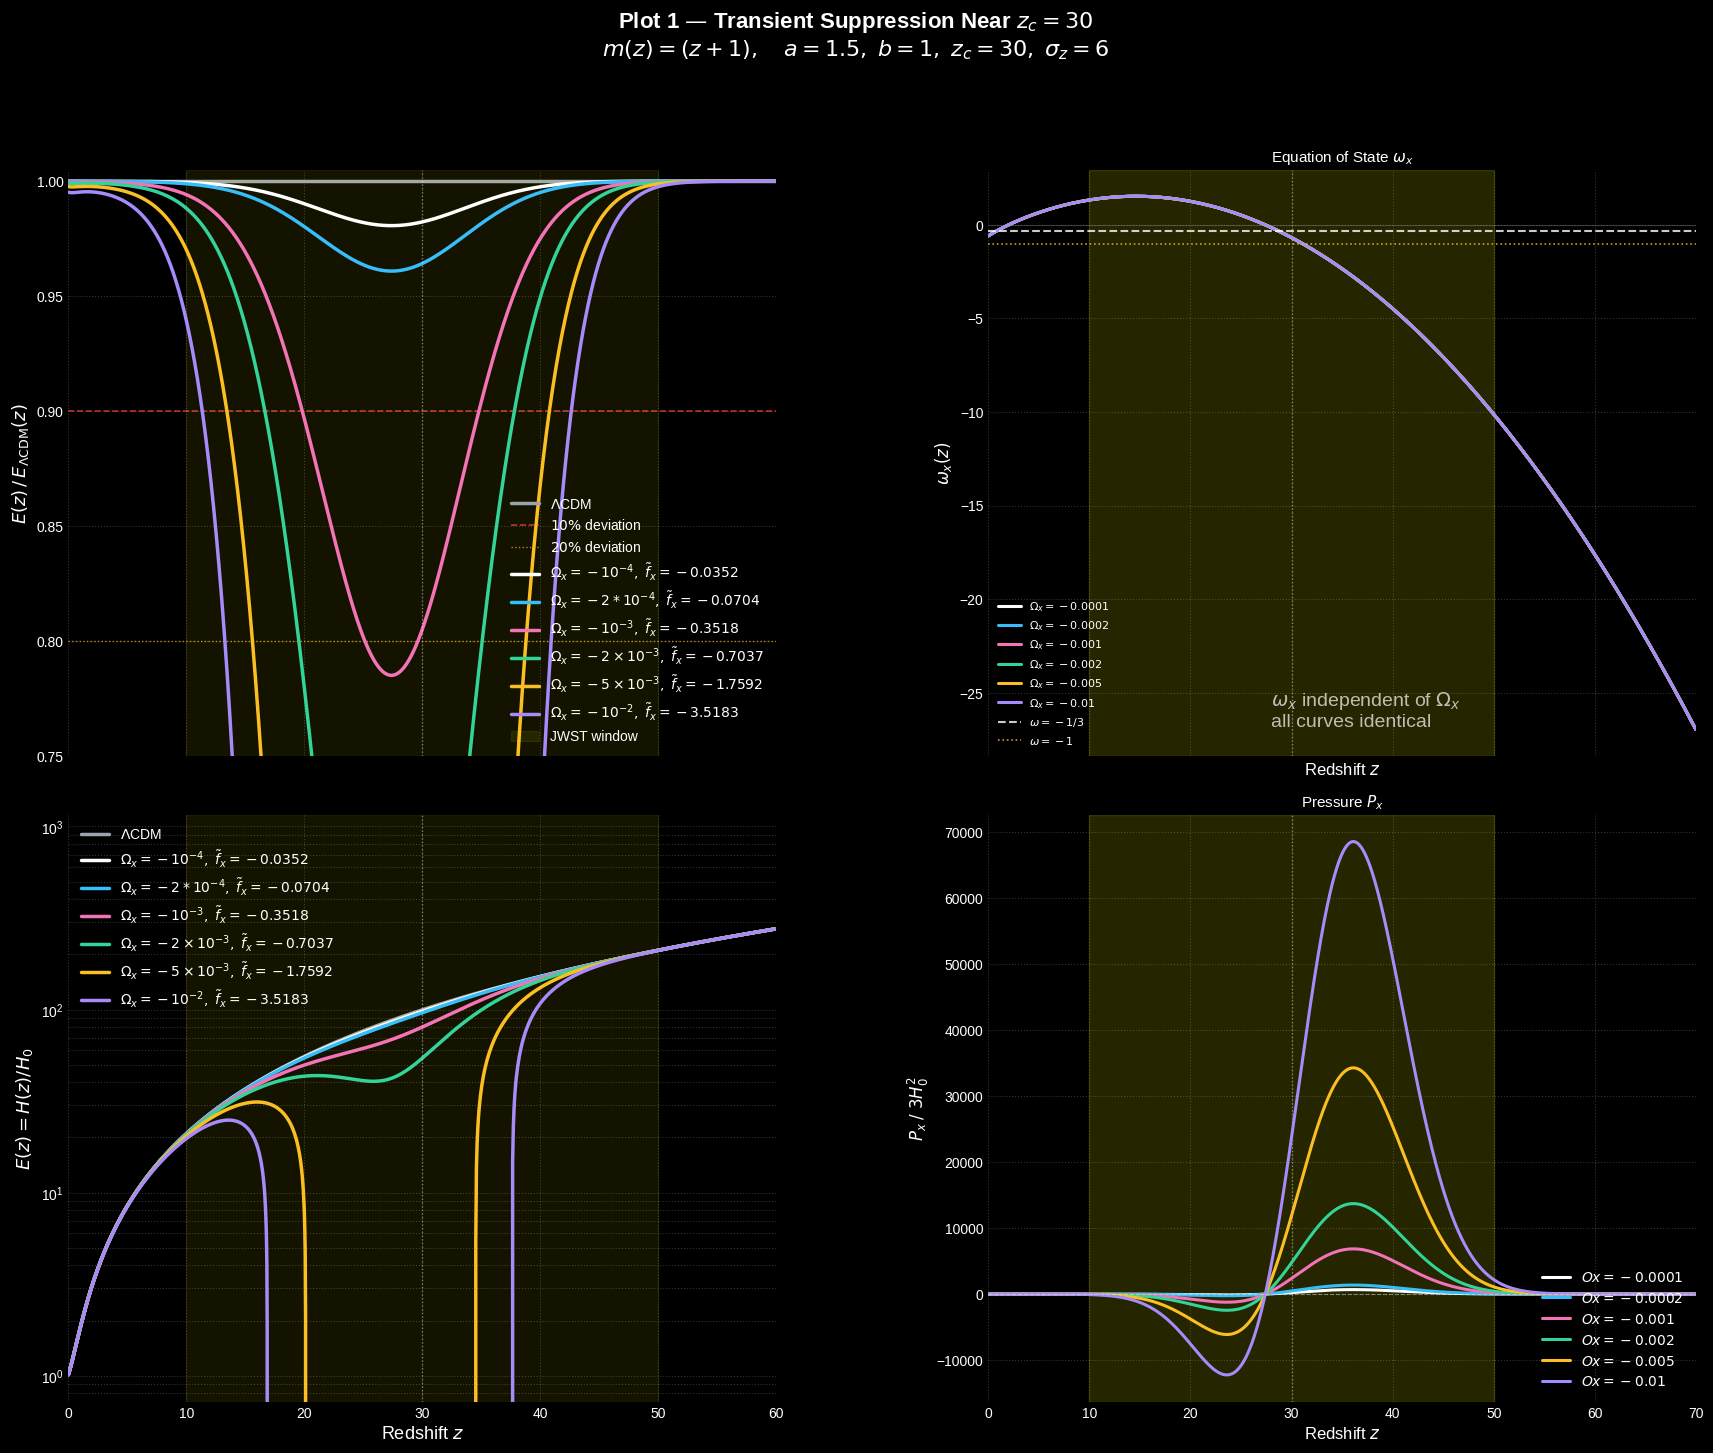

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — The Money Shot: Localization Working Perfectly
# a=1.5, b=1, z_c=30, sigma_z=6 | Amplitude sweep
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

A1, B1, ZC1, SZ1 = 1.5, 1.0, 30, 6
PARAMS_P1 = [
    dict(Ox=-1e-4, label=r"$\Omega_x = -10^{-4}$"),
    dict(Ox=-2e-4, label=r"$\Omega_x = -2*10^{-4}$"),
    dict(Ox=-1e-3, label=r"$\Omega_x = -10^{-3}$"),
    dict(Ox=-2e-3, label=r"$\Omega_x = -2\times10^{-3}$"),
    dict(Ox=-5e-3, label=r"$\Omega_x = -5\times10^{-3}$"),
    dict(Ox=-1e-2, label=r"$\Omega_x = -10^{-2}$"),
    
]

COLORS_P1 = [
    '#ffffff', # 1. Pure White (Best for a baseline/reference)
    '#38bdf8', # 2. Sky Blue
    '#f472b6', # 3. Hot Pink
    '#34d399', # 4. Emerald Green
    '#fbbf24', # 5. Amber/Yellow
    '#a78bfa', # 6. Soft Purple
    '#f87171', # 7. Coral Red
    '#22d3ee', # 8. Cyan
    '#fb923c', # 9. Orange
    '#818cf8', # 10. Indigo
    '#a3e635', # 11. Lime
    '#f472b6', # 12. Rose
    '#2dd4bf', # 13. Teal
    '#e879f9', # 14. Fuchsia
    '#94a3b8'  # 15. Slate/Silver
]

z_arr  = np.logspace(-5, np.log10(125), 10000)
El_arr = Ez_lcdm(z_arr)

fig, axes = plt.subplots(2, 2, figsize=(21, 16), sharex='col')
fig.subplots_adjust(hspace=0.1, wspace=0.3)

ax_top, ax_omx = axes[0]   # left=ratio,   right=omega_x
ax_bot, ax_Px  = axes[1]   # left=raw E(z), right=P_x

fig.suptitle(
    r"Plot 1 — Transient Suppression Near $z_c=30$""\n"
    r"$m(z)=(z+1),\quad a=1.5,\;b=1,\;z_c=30,\;\sigma_z=6$",
    fontsize=16, fontweight='bold', y=0.98)

# ── Reference lines ────────────────────────────────────────────────────────────
ax_top.axhline(1.0,  color='#9ca3af', lw=2.5, ls='-',  label=r'$\Lambda$CDM', zorder=1)
ax_top.axhline(0.90, color='#ff4444', lw=1.2, ls='--', alpha=0.7, label=r'$10\%$ deviation', zorder=1)
ax_top.axhline(0.80, color='#fbbf24', lw=1.0, ls=':',  alpha=0.7, label=r'$20\%$ deviation', zorder=1)
ax_bot.plot(z_arr, El_arr, color='#9ca3af', lw=2.5, label=r'$\Lambda$CDM', zorder=1)

for p, c in zip(PARAMS_P1, COLORS_P1):
    fp   = get_fpeak_witha(p["Ox"], A1, B1, ZC1, SZ1)
    lbl  = p["label"] + rf"$,\;\tilde{{f}}_x = {fp:.4f}$"
    Ez_m = get_Ez_witha(z_arr, p["Ox"], A1, B1, ZC1, SZ1)
    ax_top.plot(z_arr, Ez_m / El_arr, color=c, lw=2.5, label=lbl, zorder=2)
    ax_bot.plot(z_arr, Ez_m,          color=c, lw=2.5, label=lbl, zorder=2)

for ax in [ax_top, ax_bot, ax_omx, ax_Px]:
    ax.axvspan(10, 50, alpha=0.08, color='yellow', label='JWST window' if ax is ax_top else '')
    ax.axvline(ZC1, color='white', lw=1.0, ls=':', alpha=0.4)
    ax.set_xlim(0, 70)
    ax.grid(True, which='both', ls=':', alpha=0.2)
    ax.legend(fontsize=10, framealpha=0.6, loc='upper left')




ax_top.set_ylabel(r'$E(z)\,/\,E_{\Lambda\mathrm{CDM}}(z)$', fontsize=13)
ax_top.tick_params(labelbottom=False)

ax_bot.set_yscale('log')
ax_bot.set_ylabel(r'$E(z) = H(z)/H_0$', fontsize=13)
ax_bot.set_xlabel(r'Redshift $z$', fontsize=13)


plot_omega_x(ax_omx, z_plot, PARAMS_P1, COLORS_P1, A1, B1, SZ1,
             model='old', sweep_key='Ox', zc_default=ZC1)        # ← change to match cell

plot_Px(ax_Px, z_plot, PARAMS_P1, COLORS_P1, A1, B1, SZ1,
        model='old', sweep_key='Ox', zc_default=ZC1)             # ← change to match cell

ax_omx.set_xlim(0, 70)
ax_Px.set_xlim(0, 70)



ax_top.set_ylim(0.75, 1.005)
ax_top.set_xlim(0,60)
ax_omx.text(0.4, 0.05,
            r"$\omega_x$ independent of $\Omega_x$" "\n" r"all curves identical",
            transform=ax_omx.transAxes, fontsize=14, color='white', alpha=0.7)
ax_top.legend(loc='lower right')
plt.legend(loc='lower right')
plt.savefig("Plot1_old_m.png", dpi=200, bbox_inches='tight')
plt.show()



/tmp/ipykernel_48927/3856689384.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, framealpha=0.6, loc='upper left')


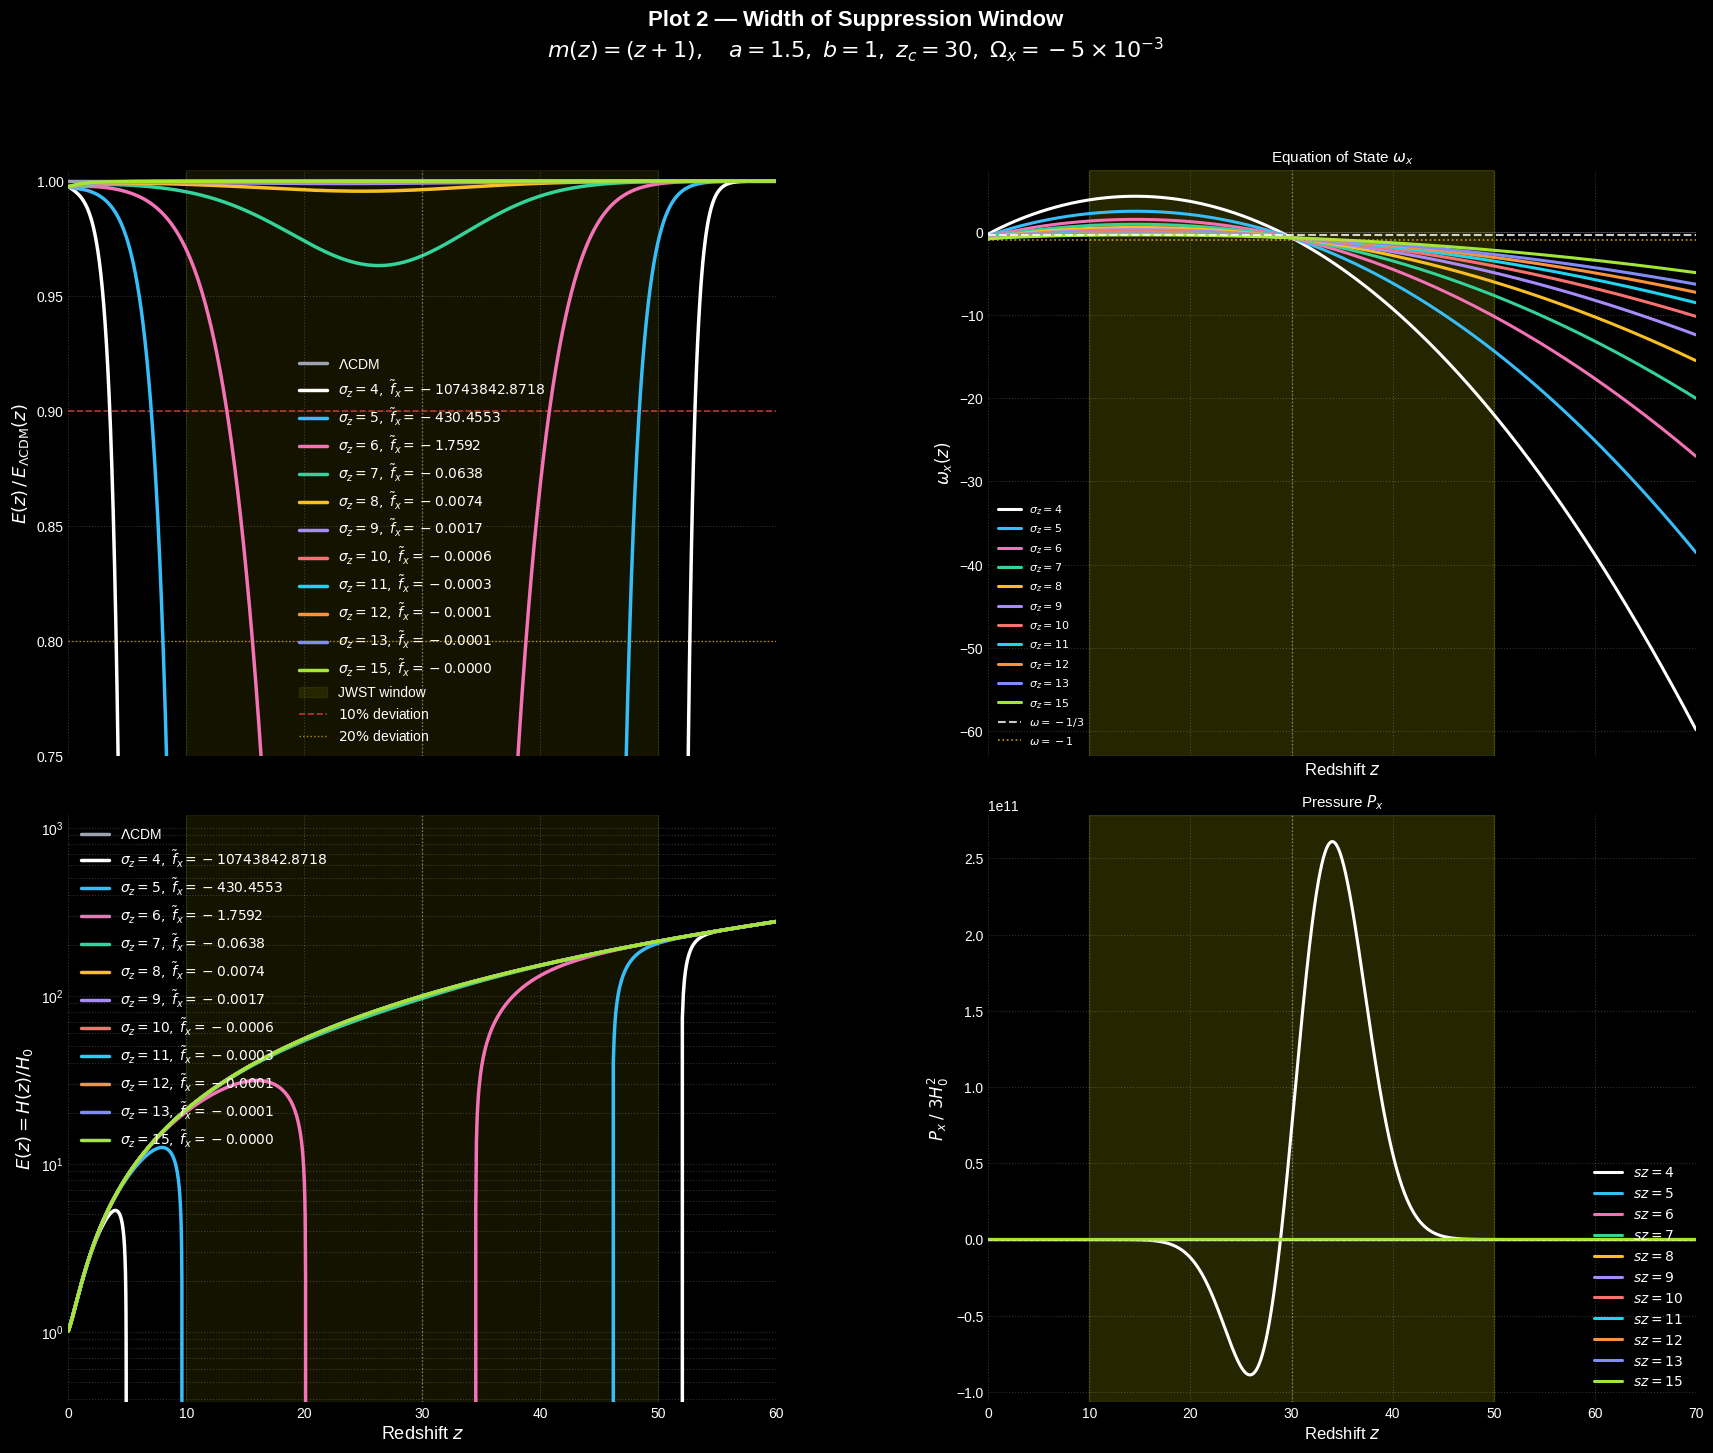

In [18]:

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Width Sweep: How Localized Does It Need To Be?
# a=1.5, b=1, z_c=30, Omega_x=-5e-3 | sigma_z sweep
# ═══════════════════════════════════════════════════════════════════════════════

A2, B2, ZC2, OX2 = 1.5, 1.0, 30, -5e-3

PARAMS_P2 = [
    dict(sz=4,  label=r"$\sigma_z = 4$"),
    dict(sz=5, label=r"$\sigma_z = 5$"),
    dict(sz=6,  label=r"$\sigma_z = 6$"),
    dict(sz=7, label=r"$\sigma_z = 7$"),
    dict(sz=8, label=r"$\sigma_z = 8$"),
    dict(sz=9, label=r"$\sigma_z = 9$"),
    dict(sz=10, label=r"$\sigma_z = 10$"),
    dict(sz=11, label=r"$\sigma_z = 11$"),
    dict(sz=12, label=r"$\sigma_z = 12$"),
    dict(sz=13, label=r"$\sigma_z = 13$"),
    dict(sz=15, label=r"$\sigma_z = 15$")
]

COLORS_P2 = [
    '#ffffff', # 1. Pure White (Best for a baseline/reference)
    '#38bdf8', # 2. Sky Blue
    '#f472b6', # 3. Hot Pink
    '#34d399', # 4. Emerald Green
    '#fbbf24', # 5. Amber/Yellow
    '#a78bfa', # 6. Soft Purple
    '#f87171', # 7. Coral Red
    '#22d3ee', # 8. Cyan
    '#fb923c', # 9. Orange
    '#818cf8', # 10. Indigo
    '#a3e635', # 11. Lime
    '#f472b6', # 12. Rose
    '#2dd4bf', # 13. Teal
    '#e879f9', # 14. Fuchsia
    '#94a3b8'  # 15. Slate/Silver
]

fig, axes = plt.subplots(2, 2, figsize=(21, 16), sharex='col')
fig.subplots_adjust(hspace=0.1, wspace=0.3)

ax_top, ax_omx = axes[0]
ax_bot, ax_Px  = axes[1]

fig.suptitle(
    r"Plot 2 — Width of Suppression Window""\n"
    r"$m(z)=(z+1),\quad a=1.5,\;b=1,\;z_c=30,\;\Omega_x=-5\times10^{-3}$",
    fontsize=16, fontweight='bold', y=0.98)

ax_top.axhline(1.0, color='#9ca3af', lw=2.5, ls='-', label=r'$\Lambda$CDM', zorder=1)
ax_bot.plot(z_arr, El_arr, color='#9ca3af', lw=2.5, label=r'$\Lambda$CDM', zorder=1)

for p, c in zip(PARAMS_P2, COLORS_P2):
    fp   = get_fpeak_witha(OX2, A2, B2, ZC2, p['sz'])
    lbl = p["label"] + rf"$,\;\tilde{{f}}_x = {fp:.4f}$"
    Ez_m = get_Ez_witha(z_arr, OX2, A2, B2, ZC2, p["sz"])
    ax_top.plot(z_arr, Ez_m / El_arr, color=c, lw=2.5, label=lbl, zorder=2)
    ax_bot.plot(z_arr, Ez_m,          color=c, lw=2.5, label=lbl, zorder=2)

for ax in [ax_top, ax_bot, ax_omx, ax_Px]:
    ax.axvspan(10, 50, alpha=0.08, color='yellow', label='JWST window' if ax is ax_top else '')
    ax.axvline(ZC2, color='white', lw=1.0, ls=':', alpha=0.4)
    ax.set_xlim(0, 70)
    ax.grid(True, which='both', ls=':', alpha=0.2)
    ax.legend(fontsize=10, framealpha=0.6, loc='upper left')

ax_top.set_ylim(0.965, 1.005)
ax_top.set_ylabel(r'$E(z)\,/\,E_{\Lambda\mathrm{CDM}}(z)$', fontsize=13)
ax_top.tick_params(labelbottom=False)

ax_bot.set_yscale('log')
ax_bot.set_ylabel(r'$E(z) = H(z)/H_0$', fontsize=13)
ax_bot.set_xlabel(r'Redshift $z$', fontsize=13)


plot_omega_x(ax_omx, z_plot, PARAMS_P2, COLORS_P2, A2, B2, sz=None,
             model='old', sweep_key='sz', zc_default=ZC2)

# plot_Px call — same, drop SZ2 (undefined anyway for a sweep)
plot_Px(ax_Px, z_plot, PARAMS_P2, COLORS_P2, A2, B2, sz=None,
        model='old', sweep_key='sz', zc_default=ZC2, Ox_default=OX2)

ax_omx.set_xlim(0, 70)
ax_Px.set_xlim(0, 70)



ax_top.set_ylim(0.75, 1.005)
ax_top.set_xlim(0,60)
ax_top.axhline(0.90, color='#ff4444', lw=1.2, ls='--', alpha=0.7, label=r'$10\%$ deviation', zorder=1)
ax_top.axhline(0.80, color='#fbbf24', lw=1.0, ls=':',  alpha=0.7, label=r'$20\%$ deviation', zorder=1)
ax_top.legend(loc='lower center')
plt.legend(loc='lower right')
plt.savefig("Plot2_old_m.png", dpi=200, bbox_inches='tight')
plt.show()


/tmp/ipykernel_48927/3572236446.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, framealpha=0.6, loc='upper left')


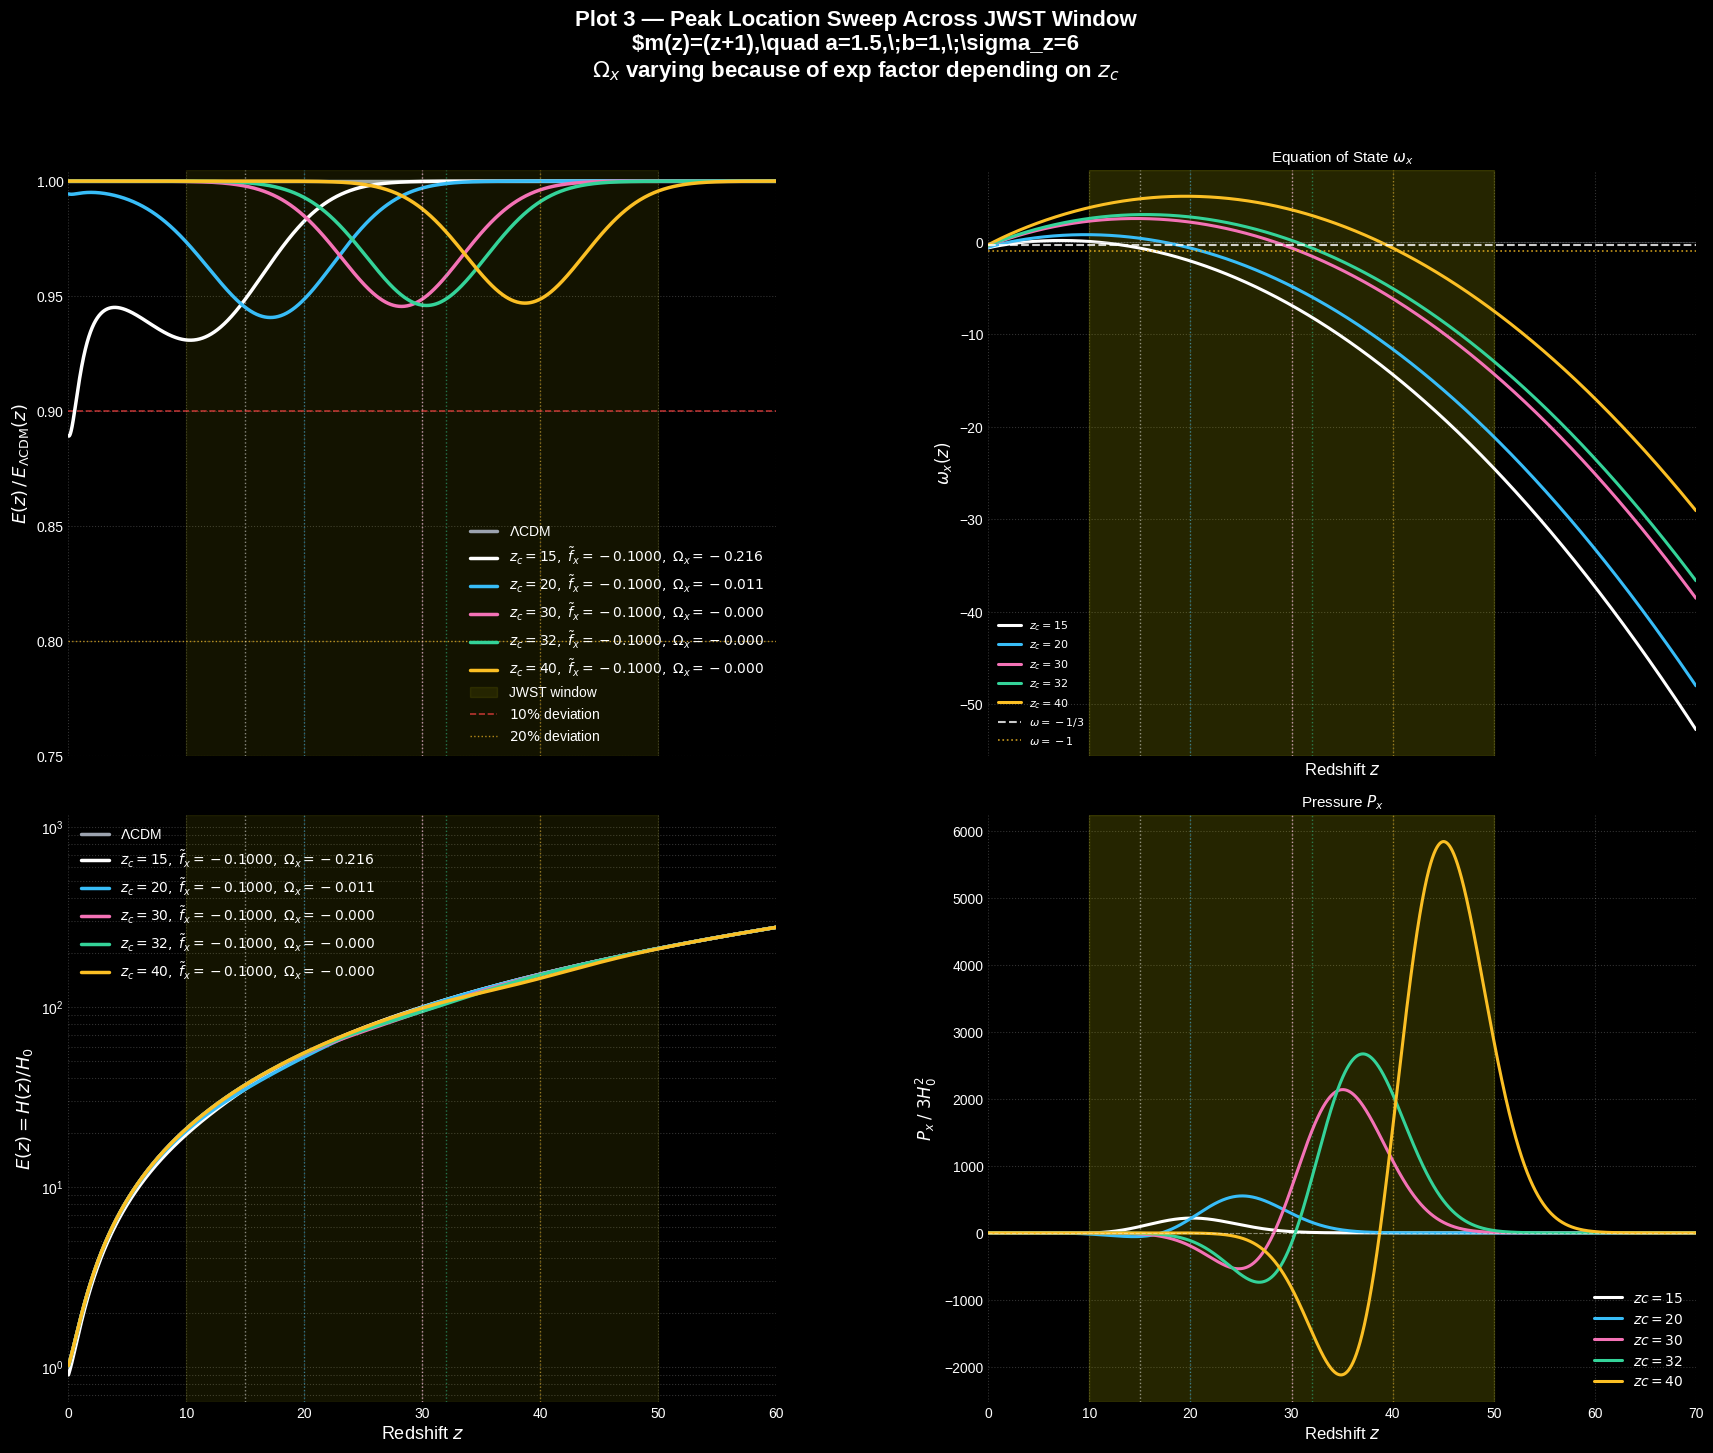

In [19]:

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — z_c Sweep: Targeting Any Epoch in the JWST Window
# a=1.5, b=1, sigma_z=6, Omega_x=-5e-3 | z_c sweep
# ═══════════════════════════════════════════════════════════════════════════════

A4, B4, SZ4 = 1.5, 1.0, 5
def Ox_from_fpeak(ftilde, a_val, b_val, zc, sz):
    """Given a desired signed f̃_x, back-calculate the required Omega_x."""
    Wpc  = calc_Wz_witha(zc, a_val, b_val, zc, sz)   # W(z_c)
    Elc2 = Ez_lcdm(np.array([zc]))[0]**2            # E²_ΛCDM(z_c)
    return ftilde * Elc2 / Wpc

FTILDE_FIXED = -0.10
PARAMS_P4 = [
    dict(zc=15, Ox=Ox_from_fpeak(FTILDE_FIXED, A4, B4, 15, SZ4),label=r"$z_c = 15$"),
    dict(zc=20, Ox=Ox_from_fpeak(FTILDE_FIXED, A4, B4, 20, SZ4),label=r"$z_c = 20$"),
    dict(zc=30, Ox=Ox_from_fpeak(FTILDE_FIXED, A4, B4, 30, SZ4),label=r"$z_c = 30$"),
    dict(zc=32, Ox=Ox_from_fpeak(FTILDE_FIXED, A4, B4, 32, SZ4),label=r"$z_c = 32$"),
    dict(zc=40, Ox=Ox_from_fpeak(FTILDE_FIXED, A4, B4, 40, SZ4),label=r"$z_c = 40$"),
]
COLORS_P4 = [
    '#ffffff', # 1. Pure White (Best for a baseline/reference)
    '#38bdf8', # 2. Sky Blue
    '#f472b6', # 3. Hot Pink
    '#34d399', # 4. Emerald Green
    '#fbbf24', # 5. Amber/Yellow
    '#a78bfa', # 6. Soft Purple
    '#f87171', # 7. Coral Red
    '#22d3ee', # 8. Cyan
    '#fb923c', # 9. Orange
    '#818cf8', # 10. Indigo
    '#a3e635', # 11. Lime
    '#f472b6', # 12. Rose
    '#2dd4bf', # 13. Teal
    '#e879f9', # 14. Fuchsia
    '#94a3b8'  # 15. Slate/Silver
]

fig, axes = plt.subplots(2, 2, figsize=(21, 16), sharex='col')
fig.subplots_adjust(hspace=0.1, wspace=0.3)

ax_top, ax_omx = axes[0]   # left=ratio,   right=omega_x
ax_bot, ax_Px  = axes[1]   # left=raw E(z), right=P_x


fig.suptitle(
    r"Plot 3 — Peak Location Sweep Across JWST Window""\n"
    r"$m(z)=(z+1),\quad a=1.5,\;b=1,\;\sigma_z=6""\n"
    r"$\Omega_x$ varying because of exp factor depending on $z_c$",
    fontsize=16, fontweight='bold', y=0.98)


ax_top.axhline(1.0, color='#9ca3af', lw=2.5, ls='-', label=r'$\Lambda$CDM', zorder=1)
ax_bot.plot(z_arr, El_arr, color='#9ca3af', lw=2.5, label=r'$\Lambda$CDM', zorder=1)

for p, c in zip(PARAMS_P4, COLORS_P4):
    fp   = get_fpeak_witha(p['Ox'], A4, B4, p['zc'], SZ4)
    lbl = p["label"] + rf"$,\;\tilde{{f}}_x = {fp:.4f}$" + rf"$, \; \Omega_x = {p['Ox']:.3f}$"
    Ez_m = get_Ez_witha(z_arr, p['Ox'], A4, B4, p["zc"], SZ4)
    ax_top.plot(z_arr, Ez_m / El_arr, color=c, lw=2.5, label=lbl, zorder=2)
    ax_bot.plot(z_arr, Ez_m,          color=c, lw=2.5, label=lbl, zorder=2)
    # Mark each z_c
    for ax in [ax_top, ax_bot, ax_omx, ax_Px]:
        ax.axvline(p["zc"], color=c, lw=1.0, ls=':', alpha=0.5)

for ax in [ax_top, ax_bot, ax_omx, ax_Px]:
    ax.axvspan(10, 50, alpha=0.08, color='yellow', label='JWST window' if ax is ax_top else '')
    ax.axvline(ZC1, color='white', lw=1.0, ls=':', alpha=0.4)
    ax.set_xlim(0, 70)
    ax.grid(True, which='both', ls=':', alpha=0.2)
    ax.legend(fontsize=10, framealpha=0.6, loc='upper left')

ax_top.set_ylim(0.965, 1.005)
ax_top.set_ylabel(r'$E(z)\,/\,E_{\Lambda\mathrm{CDM}}(z)$', fontsize=13)
ax_top.tick_params(labelbottom=False)

ax_bot.set_yscale('log')
ax_bot.set_ylabel(r'$E(z) = H(z)/H_0$', fontsize=13)
ax_bot.set_xlabel(r'Redshift $z$', fontsize=13)



plot_omega_x(ax_omx, z_plot, PARAMS_P4, COLORS_P4, A4, B4, SZ4,
             model='old', sweep_key='zc')        # ← change to match cell

plot_Px(ax_Px, z_plot, PARAMS_P4, COLORS_P4, A4, B4, SZ4,
        model='old', sweep_key='zc')             # ← change to match cell

ax_omx.set_xlim(0, 70)
ax_Px.set_xlim(0, 70)



plt.savefig("Plot3_zc_sweep_old_m.png", dpi=150, bbox_inches='tight')

ax_top.set_ylim(0.75, 1.005)
ax_top.set_xlim(0,60)
ax_top.axhline(0.90, color='#ff4444', lw=1.2, ls='--', alpha=0.7, label=r'$10\%$ deviation', zorder=1)
ax_top.axhline(0.80, color='#fbbf24', lw=1.0, ls=':',  alpha=0.7, label=r'$20\%$ deviation', zorder=1)
ax_top.legend(loc='lower right')
plt.legend(loc='lower right')
plt.savefig("Plot4_zc_sweep.png", dpi=200, bbox_inches='tight')

plt.show()


# Now to assume $\Omega_x$ in terms of $\frac{z}{(z+1)}$ instead of $(z+1)$

In [20]:
z,a, b, rho_x= symbols(r'z a b \rho_{x}(z)')
H, H_0, Omega_m, Omega_r, Omega_lambda, z_c, sigma_z = symbols(r'H H_0 \Omega_{m} \Omega_{r} \Omega_{\Lambda} z_c \sigma_z ', real=True, positive= True)

Then define the $\rho_x$ and $\Omega_x$ equations

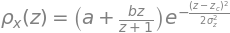

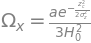

In [21]:
rhox_exp = (a+(b*((z)/(z+1)))) * sp.exp(-(z-z_c)**2/(2*(sigma_z)**2))                     

rhox_eqn = sp.Eq(rho_x, rhox_exp)

display(rhox_eqn)

rhox_zero_sym, Omega_x = symbols(r'\rho_{x}(z=0) \Omega_x')

Omegax_exp = rhox_zero_sym/(3*H_0**2)

rhox_zero = sp.Eq(rhox_zero_sym, rhox_eqn.rhs.subs(z,0))
display(rhox_zero)


Omegax_exp = Omegax_exp.subs(rhox_zero_sym, rhox_zero.rhs)


Omegax_eqn = sp.Eq(Omega_x, Omegax_exp)
display(Omegax_eqn)

Now onto the modified friedmann equation

In [22]:
Hz, Wz = symbols('H(z) \mathcal{W}(z)')
Friedmann_exp = H_0**2 * (Omega_m *(1+z)**3 + Omega_r* (1+z)**4  + Omega_lambda + Omega_x * Wz )

Friedmann_eqn = sp.Eq(Hz**2, Friedmann_exp)

display(Friedmann_eqn)


Now to find $\mathcal{W}(z)$ using $$ H(z)^2 = H_0^2 \sum_i \Omega_i \cdot f_{i}(z) $$ & $$ f_{i}(z) = \dfrac{\rho_i(z)}{\rho_i(z=0)}$$
Therefore,
$$ \mathcal{W}(z) = \dfrac{\rho_x(z)}{\rho_x(z=0)}$$

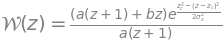

In [23]:
Wz_exp = rhox_exp/(rhox_zero.rhs)

Wz_exp = simplify(Wz_exp)

Wz_eqn = sp.Eq(Wz,Wz_exp)

display(Wz_eqn)


Before finding the final Friedmann equation form we should deduce the equation of state function for $\Omega_x$ and find $\omega_x, p_x$

$\because \dot{\rho_{DE}} + 3H(\rho_{DE}+P_{DE}) = 0$
by using the chain rule on $\rho_{DE}$ we get
$$\omega_x(z) = \dfrac{(1+z)}{\rho_x} \frac{d\rho_x}{dz}-1 $$

one can either plug the original $\rho_x$ here or use the other method of

In [24]:
# 1. Get the expression for rhox_zero_sym: [Omega_x * 3 * H_0**2]

Omegax_eqn_2 = sp.Eq(Omega_x, rhox_zero.lhs/(3*H_0))

rhox_zero_val = sp.solve(Omegax_eqn_2, rhox_zero_sym)[0]

# 2. Use your W(z) = rho_x / rhox_zero_sym equation
Wz_eqn_2 = sp.Eq(Wz, rho_x / rhox_zero_sym)

# 3. Isolate rho_x
rhox_isolated = sp.solve(Wz_eqn_2, rho_x)[0]

final_rhox_expr = rhox_isolated.subs(rhox_zero_sym, rhox_zero_val)


final_rhox_eqn = sp.Eq(rho_x, final_rhox_expr)

display(final_rhox_eqn)


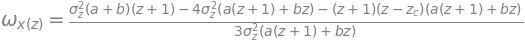

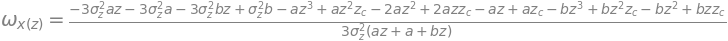

In [25]:
omega_x = symbols(r'\omega_x(z)')
omega_x


drhox_dz = sp.Derivative(rho_x,z) 
omega_x_eqn = sp.Eq(omega_x, ((1+z)/(3*rho_x))*(drhox_dz)-1)

display(omega_x_eqn)

final_rhox_expr = final_rhox_expr.subs(Wz, Wz_exp)

final_omega_eqn = omega_x_eqn.subs({
   drhox_dz: sp.diff(final_rhox_expr, z),
    rho_x: final_rhox_expr,
})

final_omega_eqn = sp.simplify(final_omega_eqn)

display(final_omega_eqn)

## OR
dW_dz = sp.Derivative(Wz_exp,z)
omega_x_eqn_2 = sp.Eq(omega_x, ((1+z)/(3*Wz))*(dW_dz)-1)
omega_x_eqn_final = omega_x_eqn_2.subs({dW_dz:dW_dz.doit(), Wz:Wz_exp})

omega_x_eqn_final = simplify(omega_x_eqn_final)

display(omega_x_eqn_final)


Or the much cleaner 
$$\omega_x(z) = \dfrac{1}{3} \cdot \left[\dfrac{b}{a(1+z)+bz}+\dfrac{(1+z)(z_c-z)}{\sigma_z^2}\right]-1$$
now onto $P_x$, which is just $P_x = \omega_x \cdot \rho_x$

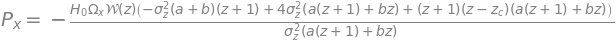

In [26]:
P_x = symbols('P_x')
P_x_eqn = sp.Eq(P_x,final_omega_eqn.rhs * final_rhox_eqn.rhs)

P_x_eqn = simplify(P_x_eqn)

P_x_eqn

... or the much cleaner $$ P_x = \Omega_x \cdot 3H_0^2 \cdot \mathcal{W}(z)\cdot \left\{\dfrac{1}{3} \cdot \left[\dfrac{b}{a(1+z)+bz}+\dfrac{(1+z)(z_c-z)}{\sigma_z^2}\right]-1\right\}$$

Therefore the final form of the modified Friedmann equation becomes:

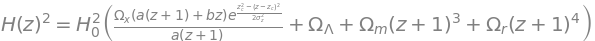

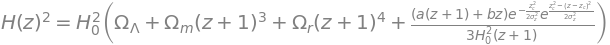

In [27]:
final_Friedmann = sp.Eq(Hz**2, Friedmann_exp.subs(Wz,Wz_exp))
display(final_Friedmann)

#final_Friedmann = simplify(final_Friedmann)

final_Friedmann = sp.Eq(Hz**2, final_Friedmann.rhs.subs(Omega_x,Omegax_exp))   #Rewrite using a,b only
display(final_Friedmann)

### Defining the Peak Fractional Energy ($\tilde{f}_x$)

* **What it means:** $\tilde{f}_x$ represents the **maximum fractional energy contribution** of the modified gravity component. Because the exotic energy is highly localized at high redshift, its present-day density ($\Omega_x$) is infinitesimally small. $\tilde{f}_x$ translates this into a physically meaningful parameter, telling us exactly what percentage of the universe's total energy budget the modification accounts for at its peak.
* **Mathematical Definition:** It is defined as the absolute ratio of the exotic energy density to the standard $\Lambda$CDM baseline energy density, evaluated strictly at the transition redshift $z_c$: $$\tilde{f}_x = \frac{|\Omega_x \mathcal{W}(z_c)|}{E_{\Lambda CDM}^2(z_c)}$$
* **SymPy Implementation:** To derive this symbolically, we evaluate the isolated window function $\mathcal{W}(z)$ at $z = z_c$, multiply by the amplitude $\Omega_x$, and divide by the standard Friedmann expansion rate $E^2(z_c)$ (which is the full Friedmann equation evaluated with $\Omega_x = 0$).

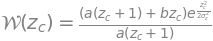

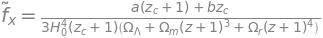

In [28]:
Wz_peak, fx= symbols(r'\mathcal{W}(z_c) \tilde{f}_x')

E2_LCDM_zc = symbols('E_{LCDM}^2(z_{c})')

Wz_peak_eq = sp.Eq(Wz_peak, Wz_eqn.subs(z, z_c).rhs)

display(Wz_peak_eq)

Wz_eq_final = sp.Eq(Wz, Wz_exp.subs(a, a_exp)) #IN TERMS OF b, Omega_x

fx_peak = sp.Eq(fx, (Omega_x * Wz_peak_eq.lhs) /E2_LCDM_zc)

fx_peak_eqn = fx_peak.subs({
    Omega_x: Omegax_exp,
    Wz_peak: Wz_peak_eq.rhs,
    E2_LCDM_zc : Friedmann_eqn.rhs.subs(Omega_x, 0)
})

display(fx_peak_eqn)

In [29]:
# ── Symbolic variables (re-declare here so cell is self-contained) ────────────
z, H_0 = sp.symbols('z H_0', positive=True)
Omega_r, Omega_m, Omega_lambda, Omega_x = sp.symbols(
    'Omega_r Omega_m Omega_lambda Omega_x', real=True)
a, b, z_c, sigma_z = sp.symbols('a b z_c sigma_z', real=True)

# ── NEW: W(z) for m(z) = z/(z+1) ─────────────────────────────────────────────
#
#   rho_x(z) = [a + b*z/(z+1)] * exp(-(z-zc)²/2σ²)
#            = [a(1+z) + bz]/(1+z) * exp(-(z-zc)²/2σ²)
#
#   rho_x(0) = a * exp(-zc²/2σ²)          ← b-term vanishes at z=0
#
#   W(z) = rho_x(z)/rho_x(0)
#         = [a(1+z)+bz] / [a(1+z)] * exp((zc² - (z-zc)²) / 2σ²)

Wz_new_exp = (
    (a*(1+z) + b*z) / (a*(1+z))
    * sp.exp((z_c**2 - (z - z_c)**2) / (2*sigma_z**2))
)

# ── NEW: Friedmann with Wz_new ────────────────────────────────────────────────
Wz = sp.Symbol('W_z')
Friedmann_exp = H_0**2 * (
    Omega_m*(1+z)**3
    + Omega_r*(1+z)**4
    + Omega_lambda
    + Omega_x * Wz
)
_Hz2_new_expr = Friedmann_exp.subs(Wz, Wz_new_exp)

In [30]:

# ── Lambdify ──────────────────────────────────────────────────────────────────
calc_Hz2_new = sp.lambdify(
    (z, H_0, Omega_r, Omega_m, Omega_lambda, Omega_x, a, b, z_c, sigma_z),
    _Hz2_new_expr, 'numpy')

calc_Wz_new = sp.lambdify(
    (z, a, b, z_c, sigma_z),
    Wz_new_exp, 'numpy')

# ── Global Cosmological Constants ─────────────────────────────────────────────
H0 = 70.0; OM = 0.33; OR = 9e-5; OL = 0.7

plt.style.use('dark_background')
COLORS = [
    '#ffffff', # 1. Pure White (Best for a baseline/reference)
    '#38bdf8', # 2. Sky Blue
    '#f472b6', # 3. Hot Pink
    '#34d399', # 4. Emerald Green
    '#fbbf24', # 5. Amber/Yellow
    '#a78bfa', # 6. Soft Purple
    '#f87171', # 7. Coral Red
    '#22d3ee', # 8. Cyan
    '#fb923c', # 9. Orange
    '#818cf8', # 10. Indigo
    '#a3e635', # 11. Lime
    '#f472b6', # 12. Rose
    '#2dd4bf', # 13. Teal
    '#e879f9', # 14. Fuchsia
    '#94a3b8'  # 15. Slate/Silver
]

# ── Shared Helpers ─────────────────────────────────────────────────────────────
def Ez_lcdm(z_arr):
    return np.sqrt(OM*(1+z_arr)**3 + OR*(1+z_arr)**4 + OL)

def get_Ez_new(z_arr, Ox, a_val, b_val, zc, sz):
    Hz2 = calc_Hz2_new(z_arr, H0, OR, OM, OL, Ox, a_val, b_val, zc, sz)
    return np.sqrt(np.maximum(Hz2, 0.0)) / H0

def get_fpeak_new(Ox, a_val, b_val, zc, sz):
    """f̃_x = |Omega_x * W(z_c)| / E²_LCDM(z_c)
       At z=zc the Gaussian = 1, so W(zc) simplifies cleanly."""
    Wp = calc_Wz_new(zc, a_val, b_val, zc, sz)
    return Ox * Wp / Ez_lcdm(np.array([zc]))[0]**2

def check_physical_new(z_arr, Ox, a_val, b_val, zc, sz):
    Hz2 = calc_Hz2_new(z_arr, H0, OR, OM, OL, Ox, a_val, b_val, zc, sz)
    bad = np.where(Hz2 <= 0)[0]
    return (True, None) if len(bad) == 0 else (False, z_arr[bad[0]])

def warn_panel(ax, z_fail, lbl):
    ax.set_facecolor('#1a0000')
    ax.text(0.5, 0.60, '⚠  H² < 0 DETECTED', transform=ax.transAxes,
            ha='center', fontsize=13, fontweight='bold', color='#ff4444')
    ax.text(0.5, 0.42, f'First failure: z ≈ {z_fail:.1f}',
            transform=ax.transAxes, ha='center', fontsize=9, color='#ffaaaa')
    ax.text(0.5, 0.26, lbl, transform=ax.transAxes, ha='center',
            fontsize=7, color='#ff8888')
    ax.set_xticks([]); ax.set_yticks([])
    [s.set_edgecolor('#ff4444') for s in ax.spines.values()]

def to_tex(val):
    if val == 0: return "0"
    e = int(np.floor(np.log10(abs(val))))
    m = round(val / 10**e, 3)
    if float(m).is_integer(): m = int(m)
    if m ==  1: return f"10^{{{e}}}"
    if m == -1: return f"-10^{{{e}}}"
    return f"{m}\\times10^{{{e}}}"



In [31]:
# # ── Sweep Parameters ──────────────────────────────────────────────────────────
# A_VAL = 15
# B_VAL = -0.25

# SWEEP_CONFIGS_NEW = [
#     {
#         "title"    : r"Sweep 1 — Amplitude $(\Omega_x)$",
#         "sweep_key": "Ox",
#         "params"   : [
#             dict(Ox=-6e-4, a=A_VAL, b=B_VAL, zc=30, sz=6),
#             dict(Ox=-2e-3, a=A_VAL, b=B_VAL, zc=30, sz=6),
#             dict(Ox=-3e-3, a=A_VAL, b=B_VAL, zc=30, sz=6),
#             dict(Ox=-4e-3, a=A_VAL, b=B_VAL, zc=30, sz=6),
#             dict(Ox=-5e-3, a=A_VAL, b=B_VAL, zc=30, sz=6),
#          #   dict(Ox=-5e-2, a=A_VAL, b=B_VAL, zc=30, sz=6),
#          #   dict(Ox=-6e-2, a=A_VAL, b=B_VAL, zc=30, sz=6),
#             dict(Ox=-1e-3, a=A_VAL, b=B_VAL, zc=30, sz=6),
#         ],
#     },
#     {
#         "title"    : r"Sweep 2 — Location $(z_c)$",
#         "sweep_key": "zc",
#         "params"   : [
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=10, sz=6),
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=20, sz=6),
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=30, sz=6),
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=50, sz=6),
#         ],
#     },
#     {
#         "title"    : r"Sweep 3 — Width $(\sigma_z)$",
#         "sweep_key": "sz",
#         "params"   : [
#             dict(Ox=-1e-3, a=A_VAL, b=B_VAL, zc=30, sz=6),
#             dict(Ox=-1e-3, a=A_VAL, b=B_VAL, zc=30, sz=7),
#             dict(Ox=-1e-3, a=A_VAL, b=B_VAL, zc=30, sz=8),
#             dict(Ox=-1e-3, a=A_VAL, b=B_VAL, zc=30, sz=9),
#                         dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=30, sz=10),
#             dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=30, sz=11),

#                         dict(Ox=-1e-2, a=A_VAL, b=B_VAL, zc=30, sz=12)

#         ],
#     },
# ]


# # ── z array: START AT 1e-3, NOT 1e-5 ─────────────────────────────────────────
# # When a=0: b/(a(1+z)+bz) = b/(bz) = 1/z → diverges as z→0.
# # z=1e-3 is safely past this; the Gaussian kills everything near z=0 anyway.
# # If a≠0, you can safely lower this to 1e-5.
# z_arr = np.logspace(-3, np.log10(125), 8000)

# El_arr = Ez_lcdm(z_arr)

# fig = plt.figure(figsize=(20, 10))
# gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
# fig.suptitle(r"$E(z)$ Sweep Analysis — $m(z) = z/(z+1)$",
#              fontsize=15, fontweight='bold')
# fig.text(0.5, 0.935,
#          rf"$a={A_VAL},b={B_VAL}$",
#          ha='center', fontsize=11, color='black',
#          bbox=dict(facecolor='#fbbf24', edgecolor='none', boxstyle='round,pad=0.3'))
# fig.text(0.03, 0.70, "Ratio to ΛCDM", va='center', ha='center',
#          rotation='vertical', fontsize=13, fontweight='bold', color='#38bdf8')
# fig.text(0.03, 0.27, r"Raw $E(z)$", va='center', ha='center',
#          rotation='vertical', fontsize=13, fontweight='bold', color='#f472b6')

# for col, cfg in enumerate(SWEEP_CONFIGS_NEW):
#     ax_top = fig.add_subplot(gs[0, col])
#     ax_bot = fig.add_subplot(gs[1, col])

#     ax_top.plot(z_arr, np.ones_like(z_arr), color='#9ca3af', lw=2, label=r'$\Lambda$CDM')
#     ax_bot.plot(z_arr, El_arr,              color='#9ca3af', lw=2, label=r'$\Lambda$CDM')

#     for i, p in enumerate(cfg["params"]):
#         lv  = p[cfg["sweep_key"]]
#         fp  = get_fpeak_new(p["Ox"], p["a"], p["b"], p["zc"], p["sz"])
#         lbl = rf"${cfg['sweep_key']}={lv},\;\tilde{{f}}_x={fp:.2e}$"
#         c   = COLORS[i % len(COLORS)]

#         ok, zbad = check_physical_new(z_arr, p["Ox"], p["a"], p["b"], p["zc"], p["sz"])
#         if not ok:
#             warn_panel(ax_top, zbad, lbl)
#             warn_panel(ax_bot, zbad, lbl)
#             continue

#         Ez_m = get_Ez_new(z_arr, p["Ox"], p["a"], p["b"], p["zc"], p["sz"])
#         ax_top.plot(z_arr, Ez_m / El_arr, color=c, lw=2,   label=lbl)
#         ax_bot.plot(z_arr, Ez_m,          color=c, lw=1.8, label=lbl)

#     for ax, ys in [(ax_top, 'linear'), (ax_bot, 'log')]:
#         ax.set_xlim(0, 70); ax.set_yscale(ys)
#         ax.set_xlabel(r'Redshift $z$', fontsize=10)
#         ax.set_title(cfg["title"], fontsize=10)
#         ax.legend(fontsize=7, framealpha=0.5)
#         ax.grid(True, which='both', ls=':', alpha=0.25)
#         ax.axvspan(10, 50, alpha=0.07, color='yellow')

#     ax_top.axhline(0.80, color='#ff4444', lw=1.2, ls='--', label='20% max')
#     ax_top.axhline(0.90, color='#fbbf24', lw=1.0, ls=':',  label='10% guide')
#     ax_top.set_ylim(0.75, 1.03)
#     ax_top.set_ylabel(r'$E(z)/E_{\Lambda\mathrm{CDM}}(z)$', fontsize=10)
#     ax_bot.set_ylabel(r'$E(z)=H(z)/H_0$', fontsize=10)

# plt.savefig("Cell1_Ez_mz_new.png", dpi=150, bbox_inches='tight')
# plt.show()

# # small enough Omega_x --> no wobble in low z

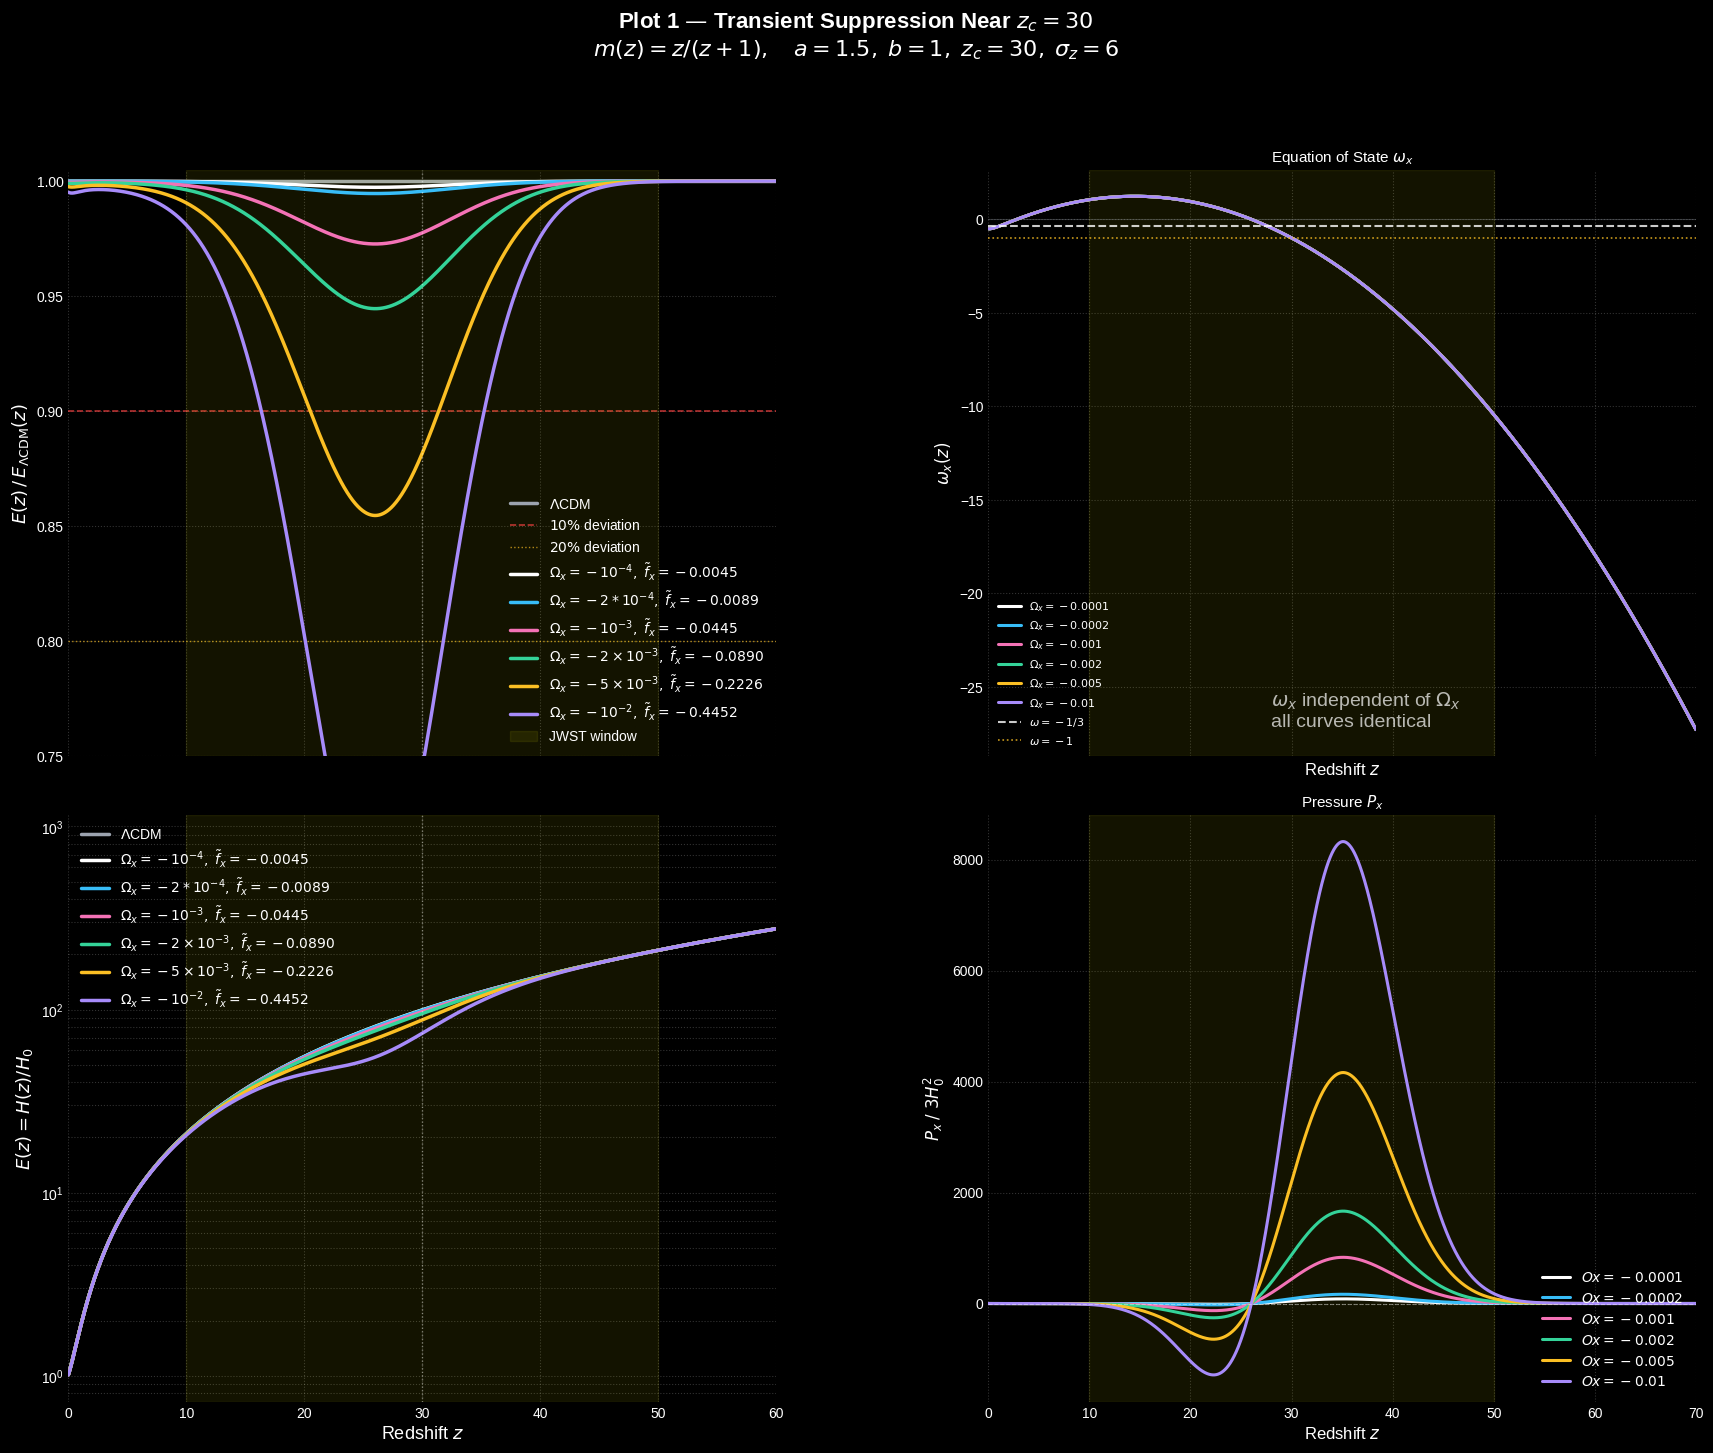

In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — The Money Shot: Localization Working Perfectly
# a=1.5, b=1, z_c=30, sigma_z=6 | Amplitude sweep
# ═══════════════════════════════════════════════════════════════════════════════
z_plot = np.linspace(1e-5, 70, 7000)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

A1, B1, ZC1, SZ1 = 1.5, 1.0, 30, 6
PARAMS_P1 = [
    dict(Ox=-1e-4, label=r"$\Omega_x = -10^{-4}$"),
    dict(Ox=-2e-4, label=r"$\Omega_x = -2*10^{-4}$"),
    dict(Ox=-1e-3, label=r"$\Omega_x = -10^{-3}$"),
    dict(Ox=-2e-3, label=r"$\Omega_x = -2\times10^{-3}$"),
    dict(Ox=-5e-3, label=r"$\Omega_x = -5\times10^{-3}$"),
    dict(Ox=-1e-2, label=r"$\Omega_x = -10^{-2}$"),
    
]

COLORS_P1 = [
    '#ffffff', # 1. Pure White (Best for a baseline/reference)
    '#38bdf8', # 2. Sky Blue
    '#f472b6', # 3. Hot Pink
    '#34d399', # 4. Emerald Green
    '#fbbf24', # 5. Amber/Yellow
    '#a78bfa', # 6. Soft Purple
    '#f87171', # 7. Coral Red
    '#22d3ee', # 8. Cyan
    '#fb923c', # 9. Orange
    '#818cf8', # 10. Indigo
    '#a3e635', # 11. Lime
    '#f472b6', # 12. Rose
    '#2dd4bf', # 13. Teal
    '#e879f9', # 14. Fuchsia
    '#94a3b8'  # 15. Slate/Silver
]

z_arr  = np.logspace(-5, np.log10(125), 10000)
El_arr = Ez_lcdm(z_arr)

fig, axes = plt.subplots(2, 2, figsize=(21, 16), sharex='col')
fig.subplots_adjust(hspace=0.1, wspace=0.3)

ax_top, ax_omx = axes[0]   # left=ratio,   right=omega_x
ax_bot, ax_Px  = axes[1]   # left=raw E(z), right=P_x

fig.suptitle(
    r"Plot 1 — Transient Suppression Near $z_c=30$""\n"
    r"$m(z)=z/(z+1),\quad a=1.5,\;b=1,\;z_c=30,\;\sigma_z=6$",
    fontsize=16, fontweight='bold', y=0.98)

# ── Reference lines ────────────────────────────────────────────────────────────
ax_top.axhline(1.0,  color='#9ca3af', lw=2.5, ls='-',  label=r'$\Lambda$CDM', zorder=1)
ax_top.axhline(0.90, color='#ff4444', lw=1.2, ls='--', alpha=0.7, label=r'$10\%$ deviation', zorder=1)
ax_top.axhline(0.80, color='#fbbf24', lw=1.0, ls=':',  alpha=0.7, label=r'$20\%$ deviation', zorder=1)
ax_bot.plot(z_arr, El_arr, color='#9ca3af', lw=2.5, label=r'$\Lambda$CDM', zorder=1)

for p, c in zip(PARAMS_P1, COLORS_P1):
    fp   = get_fpeak_new(p["Ox"], A1, B1, ZC1, SZ1)
    lbl  = p["label"] + rf"$,\;\tilde{{f}}_x = {fp:.4f}$"
    Ez_m = get_Ez_new(z_arr, p["Ox"], A1, B1, ZC1, SZ1)
    ax_top.plot(z_arr, Ez_m / El_arr, color=c, lw=2.5, label=lbl, zorder=2)
    ax_bot.plot(z_arr, Ez_m,          color=c, lw=2.5, label=lbl, zorder=2)

for ax in [ax_top,ax_bot]:
    ax.axvspan(10, 50, alpha=0.08, color='yellow', label='JWST window' if ax is ax_top else '')
    ax.axvline(ZC1, color='white', lw=1.0, ls=':', alpha=0.4)
    ax.set_xlim(0, 70)
    ax.grid(True, which='both', ls=':', alpha=0.2)
    ax.legend(fontsize=10, framealpha=0.6, loc='upper left')




ax_top.set_ylabel(r'$E(z)\,/\,E_{\Lambda\mathrm{CDM}}(z)$', fontsize=13)
ax_top.tick_params(labelbottom=False)

ax_bot.set_yscale('log')
ax_bot.set_ylabel(r'$E(z) = H(z)/H_0$', fontsize=13)
ax_bot.set_xlabel(r'Redshift $z$', fontsize=13)


plot_omega_x(ax_omx, z_plot, PARAMS_P1, COLORS_P1, A1, B1, SZ1,
             model='new', sweep_key='Ox', zc_default=ZC1)        # ← change to match cell

plot_Px(ax_Px, z_plot, PARAMS_P1, COLORS_P1, A1, B1, SZ1,
        model='new', sweep_key='Ox', zc_default=ZC1)             # ← change to match cell

ax_omx.set_xlim(0, 70)
ax_Px.set_xlim(0, 70)



ax_top.set_ylim(0.75, 1.005)
ax_top.set_xlim(0,60)
ax_omx.text(0.4, 0.05,
            r"$\omega_x$ independent of $\Omega_x$" "\n" r"all curves identical",
            transform=ax_omx.transAxes, fontsize=14, color='white', alpha=0.7)
ax_top.legend(loc='lower right')
plt.legend(loc='lower right')
plt.savefig("Plot1.png", dpi=200, bbox_inches='tight')
plt.show()



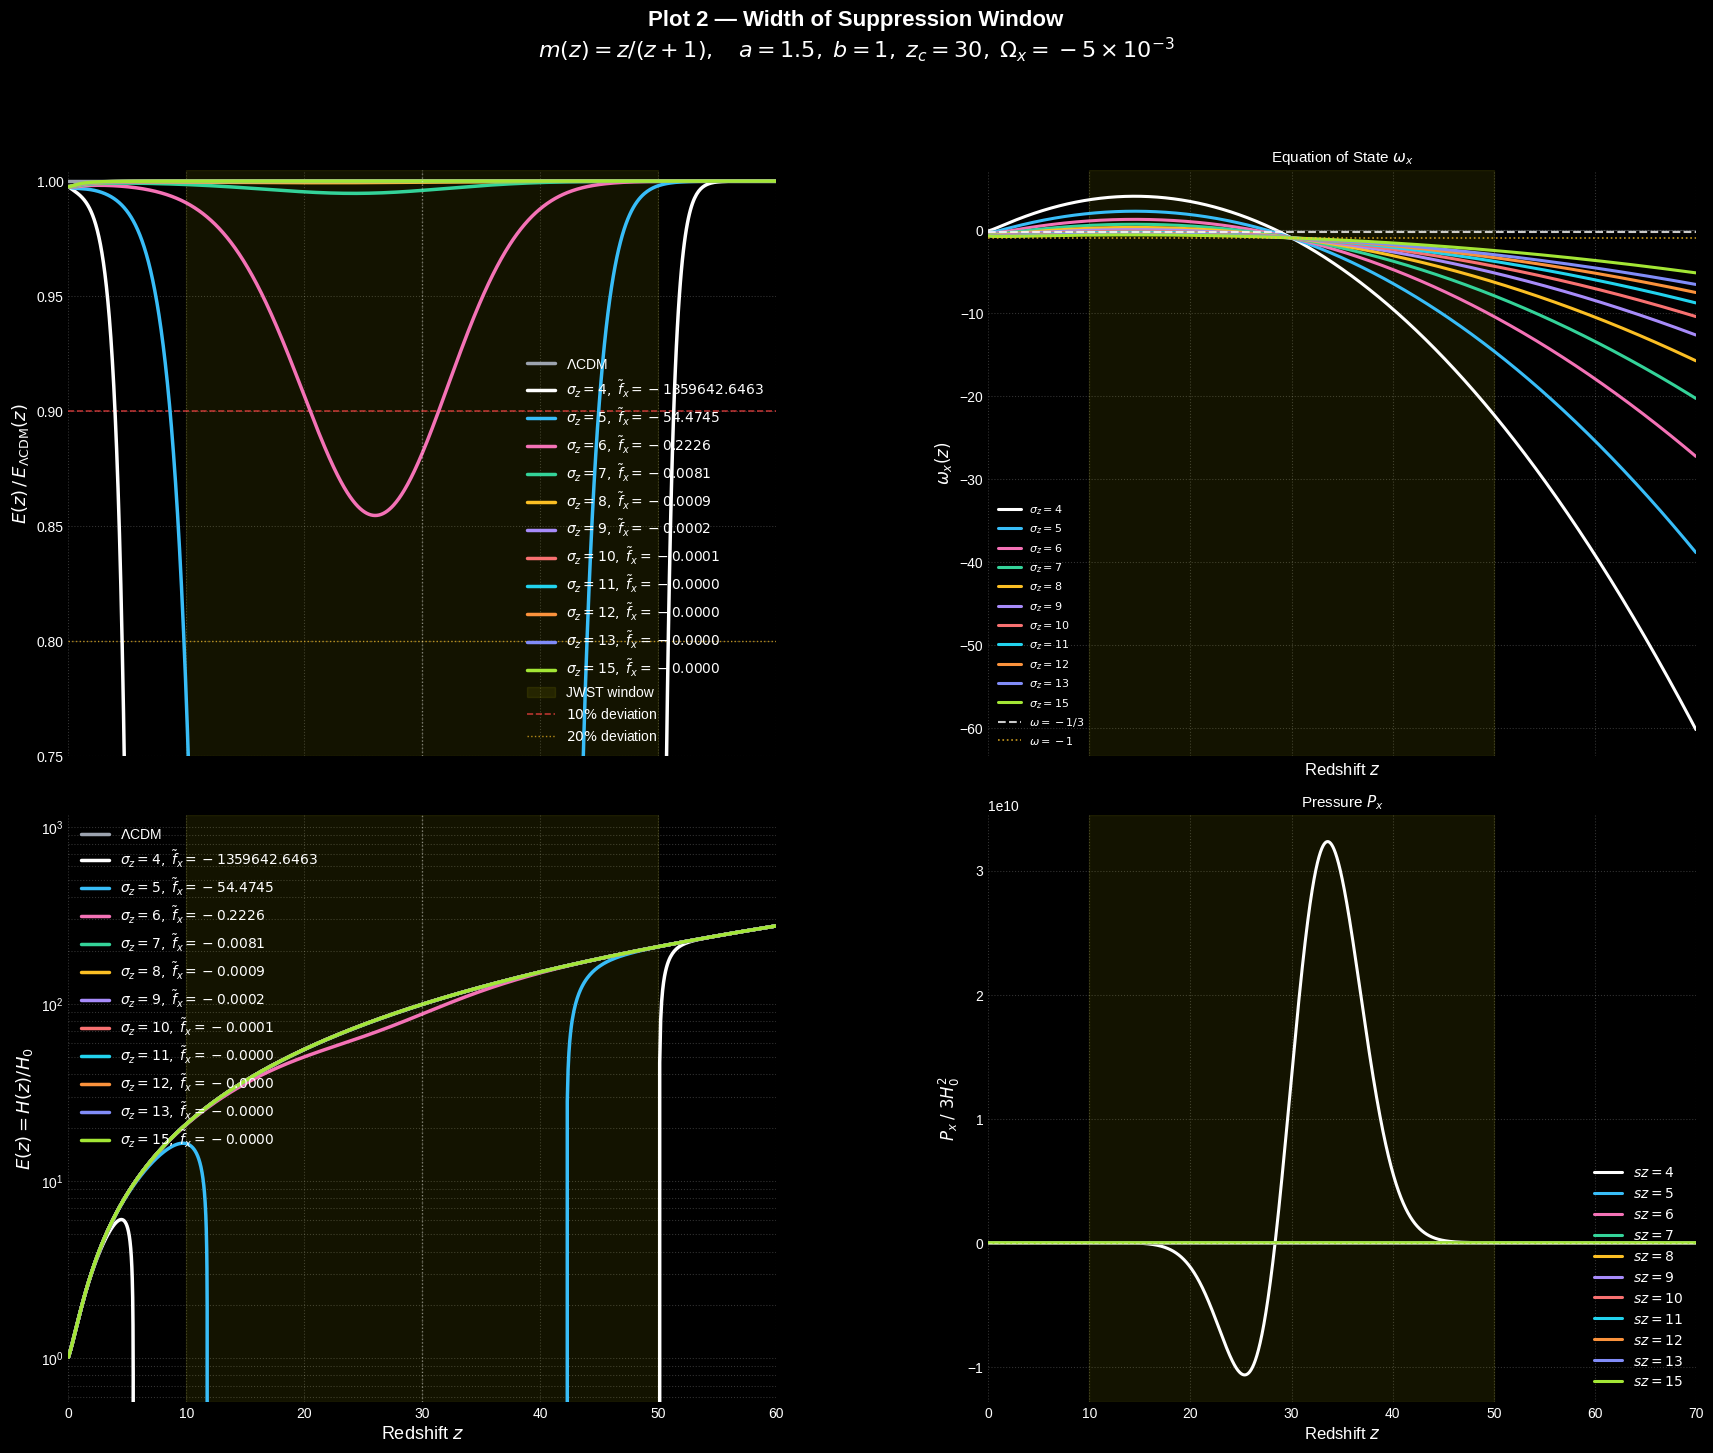

In [33]:

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Width Sweep: How Localized Does It Need To Be?
# a=1.5, b=1, z_c=30, Omega_x=-5e-3 | sigma_z sweep
# ═══════════════════════════════════════════════════════════════════════════════

A2, B2, ZC2, OX2 = 1.5, 1.0, 30, -5e-3

PARAMS_P2 = [
    dict(sz=4,  label=r"$\sigma_z = 4$"),
    dict(sz=5, label=r"$\sigma_z = 5$"),
    dict(sz=6,  label=r"$\sigma_z = 6$"),
    dict(sz=7, label=r"$\sigma_z = 7$"),
    dict(sz=8, label=r"$\sigma_z = 8$"),
    dict(sz=9, label=r"$\sigma_z = 9$"),
    dict(sz=10, label=r"$\sigma_z = 10$"),
    dict(sz=11, label=r"$\sigma_z = 11$"),
    dict(sz=12, label=r"$\sigma_z = 12$"),
    dict(sz=13, label=r"$\sigma_z = 13$"),
    dict(sz=15, label=r"$\sigma_z = 15$")
]

COLORS_P2 = [
    '#ffffff', # 1. Pure White (Best for a baseline/reference)
    '#38bdf8', # 2. Sky Blue
    '#f472b6', # 3. Hot Pink
    '#34d399', # 4. Emerald Green
    '#fbbf24', # 5. Amber/Yellow
    '#a78bfa', # 6. Soft Purple
    '#f87171', # 7. Coral Red
    '#22d3ee', # 8. Cyan
    '#fb923c', # 9. Orange
    '#818cf8', # 10. Indigo
    '#a3e635', # 11. Lime
    '#f472b6', # 12. Rose
    '#2dd4bf', # 13. Teal
    '#e879f9', # 14. Fuchsia
    '#94a3b8'  # 15. Slate/Silver
]

fig, axes = plt.subplots(2, 2, figsize=(21, 16), sharex='col')
fig.subplots_adjust(hspace=0.1, wspace=0.3)

ax_top, ax_omx = axes[0]
ax_bot, ax_Px  = axes[1]

fig.suptitle(
    r"Plot 2 — Width of Suppression Window""\n"
    r"$m(z)=z/(z+1),\quad a=1.5,\;b=1,\;z_c=30,\;\Omega_x=-5\times10^{-3}$",
    fontsize=16, fontweight='bold', y=0.98)

ax_top.axhline(1.0, color='#9ca3af', lw=2.5, ls='-', label=r'$\Lambda$CDM', zorder=1)
ax_bot.plot(z_arr, El_arr, color='#9ca3af', lw=2.5, label=r'$\Lambda$CDM', zorder=1)

for p, c in zip(PARAMS_P2, COLORS_P2):
    fp   = get_fpeak_new(OX2, A2, B2, ZC2, p['sz'])
    lbl = p["label"] + rf"$,\;\tilde{{f}}_x = {fp:.4f}$"
    Ez_m = get_Ez_new(z_arr, OX2, A2, B2, ZC2, p["sz"])
    ax_top.plot(z_arr, Ez_m / El_arr, color=c, lw=2.5, label=lbl, zorder=2)
    ax_bot.plot(z_arr, Ez_m,          color=c, lw=2.5, label=lbl, zorder=2)

for ax in [ax_top,ax_bot]:
    ax.axvspan(10, 50, alpha=0.08, color='yellow', label='JWST window' if ax is ax_top else '')
    ax.axvline(ZC2, color='white', lw=1.0, ls=':', alpha=0.4)
    ax.set_xlim(0, 70)
    ax.grid(True, which='both', ls=':', alpha=0.2)
    ax.legend(fontsize=10, framealpha=0.6, loc='upper left')

ax_top.set_ylim(0.965, 1.005)
ax_top.set_ylabel(r'$E(z)\,/\,E_{\Lambda\mathrm{CDM}}(z)$', fontsize=13)
ax_top.tick_params(labelbottom=False)

ax_bot.set_yscale('log')
ax_bot.set_ylabel(r'$E(z) = H(z)/H_0$', fontsize=13)
ax_bot.set_xlabel(r'Redshift $z$', fontsize=13)


plot_omega_x(ax_omx, z_plot, PARAMS_P2, COLORS_P2, A2, B2, sz=None,
             model='new', sweep_key='sz', zc_default=ZC2)

# plot_Px call — same, drop SZ2 (undefined anyway for a sweep)
plot_Px(ax_Px, z_plot, PARAMS_P2, COLORS_P2, A2, B2, sz=None,
        model='new', sweep_key='sz', zc_default=ZC2, Ox_default=OX2)

ax_omx.set_xlim(0, 70)
ax_Px.set_xlim(0, 70)


plt.savefig("Plot2.png", dpi=200)

ax_top.set_ylim(0.75, 1.005)
ax_top.set_xlim(0,60)
ax_top.axhline(0.90, color='#ff4444', lw=1.2, ls='--', alpha=0.7, label=r'$10\%$ deviation', zorder=1)
ax_top.axhline(0.80, color='#fbbf24', lw=1.0, ls=':',  alpha=0.7, label=r'$20\%$ deviation', zorder=1)
ax_top.legend(loc='lower right')
plt.legend(loc='lower right')
plt.savefig("Plot2.png", dpi=200, bbox_inches='tight')
plt.show()


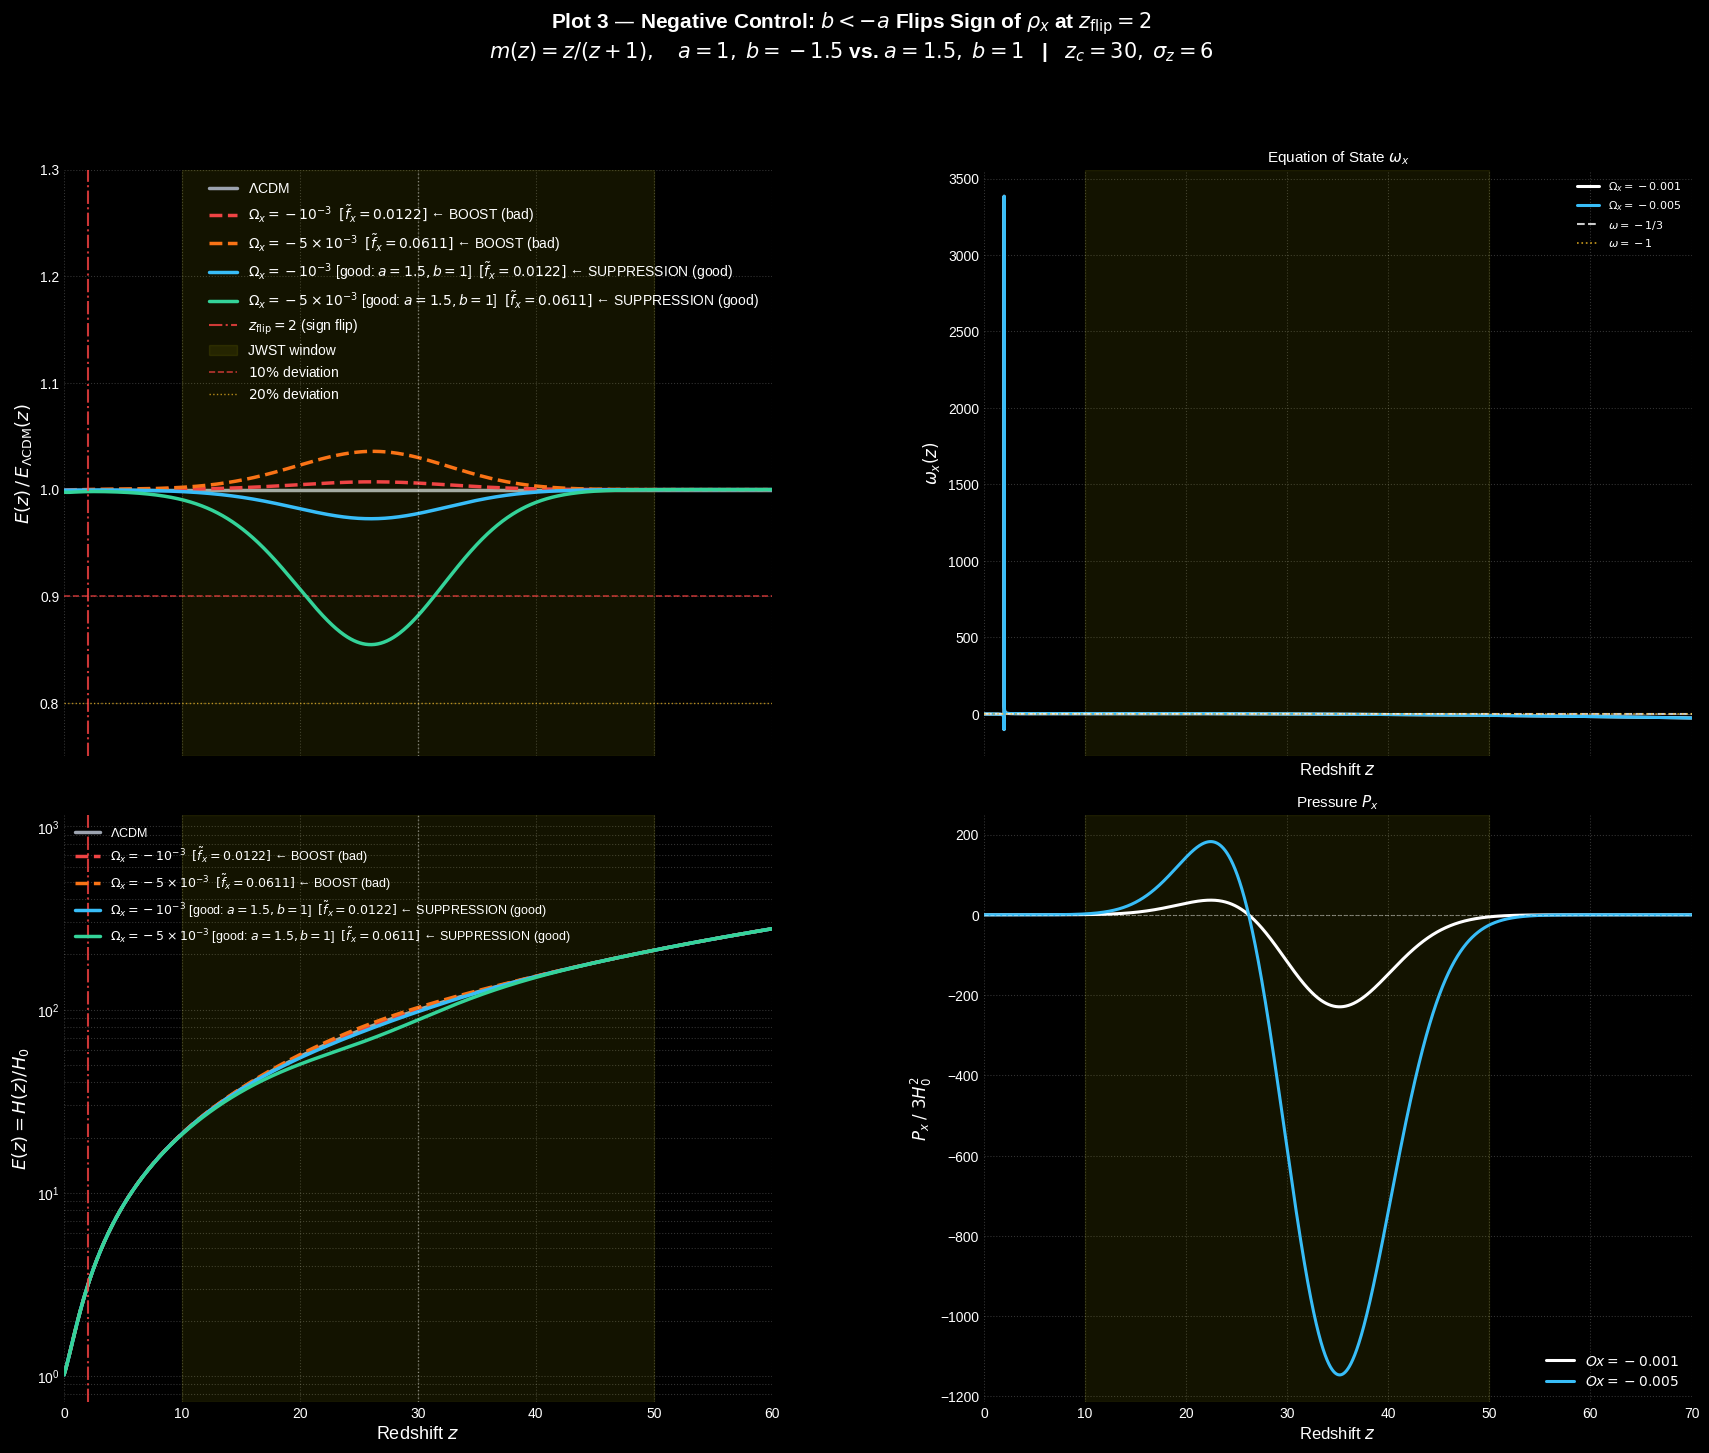

In [34]:

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Negative Control: The Backwards Case (b < -a)
# a=1, b=-1.5 → sign flip at z=2 → H(z) goes UP instead of DOWN
# ═══════════════════════════════════════════════════════════════════════════════
A3, B3, ZC3, SZ3 = 1.0, -1.5, 30, 6
PARAMS_P3 = [
    dict(Ox=-1e-3, label=r"$\Omega_x=-10^{-3}$"),
    dict(Ox=-5e-3, label=r"$\Omega_x=-5\times10^{-3}$"),
]
# Also show a=1.5, b=1 at same Omega_x for direct comparison
PARAMS_P3_GOOD = [
    dict(Ox=-1e-3, label=r"$\Omega_x=-10^{-3}$ [good: $a=1.5,b=1$]"),
    dict(Ox=-5e-3, label=r"$\Omega_x=-5\times10^{-3}$ [good: $a=1.5,b=1$]"),
]
COLORS_P3_BAD  = ['#ef4444', '#f97316']       # reds for bad
COLORS_P3_GOOD = ['#38bdf8', '#34d399']        # blues/greens for good

z_flip = A3 / abs(A3 + B3)   # = 1/0.5 = 2

fig, axes = plt.subplots(2, 2, figsize=(21, 16), sharex='col')
fig.subplots_adjust(hspace=0.1, wspace=0.3)

ax_top, ax_omx = axes[0]   # left=ratio,   right=omega_x
ax_bot, ax_Px  = axes[1]   # left=raw E(z), right=P_x


fig.suptitle(
    r"Plot 3 — Negative Control: $b < -a$ Flips Sign of $\rho_x$ at $z_{\rm flip}=2$""\n"
    r"$m(z)=z/(z+1),\quad a=1,\;b=-1.5$ vs. $a=1.5,\;b=1$   |   $z_c=30,\;\sigma_z=6$",
    fontsize=15, fontweight='bold', y=0.98)


ax_top.axhline(1.0, color='#9ca3af', lw=2.5, ls='-', label=r'$\Lambda$CDM', zorder=1)
ax_bot.plot(z_arr, El_arr, color='#9ca3af', lw=2.5, label=r'$\Lambda$CDM', zorder=1)

# Bad curves (b < -a)
for p, c in zip(PARAMS_P3, COLORS_P3_BAD):
    fp   = p["Ox"] * calc_Wz_new(ZC3, A3, B3, ZC3, SZ3) / Ez_lcdm(np.array([ZC3]))[0]**2
    lbl  = p["label"] + rf"$ \;\;[\tilde{{f}}_x={fp:.4f}]$ ← BOOST (bad)"
    Ez_m = get_Ez_new(z_arr, p["Ox"], A3, B3, ZC3, SZ3)
    ax_top.plot(z_arr, Ez_m / El_arr, color=c, lw=2.5, ls='--', label=lbl, zorder=2)
    ax_bot.plot(z_arr, Ez_m,          color=c, lw=2.5, ls='--', label=lbl, zorder=2)

# Good curves (b > -a) for comparison
for p, c in zip(PARAMS_P3_GOOD, COLORS_P3_GOOD):
    fp   = get_fpeak_new(p["Ox"], A3, B3, ZC3, SZ3)
    lbl  = p["label"] + rf"$ \;\;[\tilde{{f}}_x={fp:.4f}]$ ← SUPPRESSION (good)"
    Ez_m = get_Ez_new(z_arr, p["Ox"], 1.5, 1.0, ZC3, SZ3)
    ax_top.plot(z_arr, Ez_m / El_arr, color=c, lw=2.5, ls='-', label=lbl, zorder=2)
    ax_bot.plot(z_arr, Ez_m,          color=c, lw=2.5, ls='-', label=lbl, zorder=2)

for ax in [ax_top,ax_bot]:
    # Mark the sign flip redshift
    ax.axvline(z_flip, color='#ff4444', lw=1.5, ls='-.', alpha=0.8,
               label=rf'$z_{{\rm flip}}={z_flip:.0f}$ (sign flip)' if ax is ax_top else '')
    ax.axvspan(10, 50, alpha=0.08, color='yellow', label='JWST window' if ax is ax_top else '')
    ax.axvline(ZC3, color='white', lw=1.0, ls=':', alpha=0.4)
    ax.set_xlim(0, 70)
    ax.grid(True, which='both', ls=':', alpha=0.2)
    ax.legend(fontsize=9, framealpha=0.6, loc='upper left')

ax_top.set_ylabel(r'$E(z)\,/\,E_{\Lambda\mathrm{CDM}}(z)$', fontsize=13)
ax_top.tick_params(labelbottom=False)

plot_omega_x(ax_omx, z_plot, PARAMS_P3, COLORS_P1, A3, B3, SZ3,
             model='new', sweep_key='Ox', zc_default=ZC3)        # ← change to match cell

plot_Px(ax_Px, z_plot, PARAMS_P3, COLORS_P1, A3, B3, SZ3,
        model='new', sweep_key='Ox', zc_default=ZC3)             # ← change to match cell

ax_omx.set_xlim(0, 70)
ax_Px.set_xlim(0, 70)


ax_bot.set_yscale('log')
ax_bot.set_ylabel(r'$E(z) = H(z)/H_0$', fontsize=13)
ax_bot.set_xlabel(r'Redshift $z$', fontsize=13)

plt.savefig("Plot3.png", dpi=150, bbox_inches='tight')

ax_top.set_ylim(0.75, 1.3)
ax_top.set_xlim(0,60)
ax_top.axhline(0.90, color='#ff4444', lw=1.2, ls='--', alpha=0.7, label=r'$10\%$ deviation', zorder=1)
ax_top.axhline(0.80, color='#fbbf24', lw=1.0, ls=':',  alpha=0.7, label=r'$20\%$ deviation', zorder=1)
ax_top.legend(loc='upper right')
plt.legend(loc='lower right')
plt.savefig("Plot3.png", dpi=200, bbox_inches='tight')

plt.show()


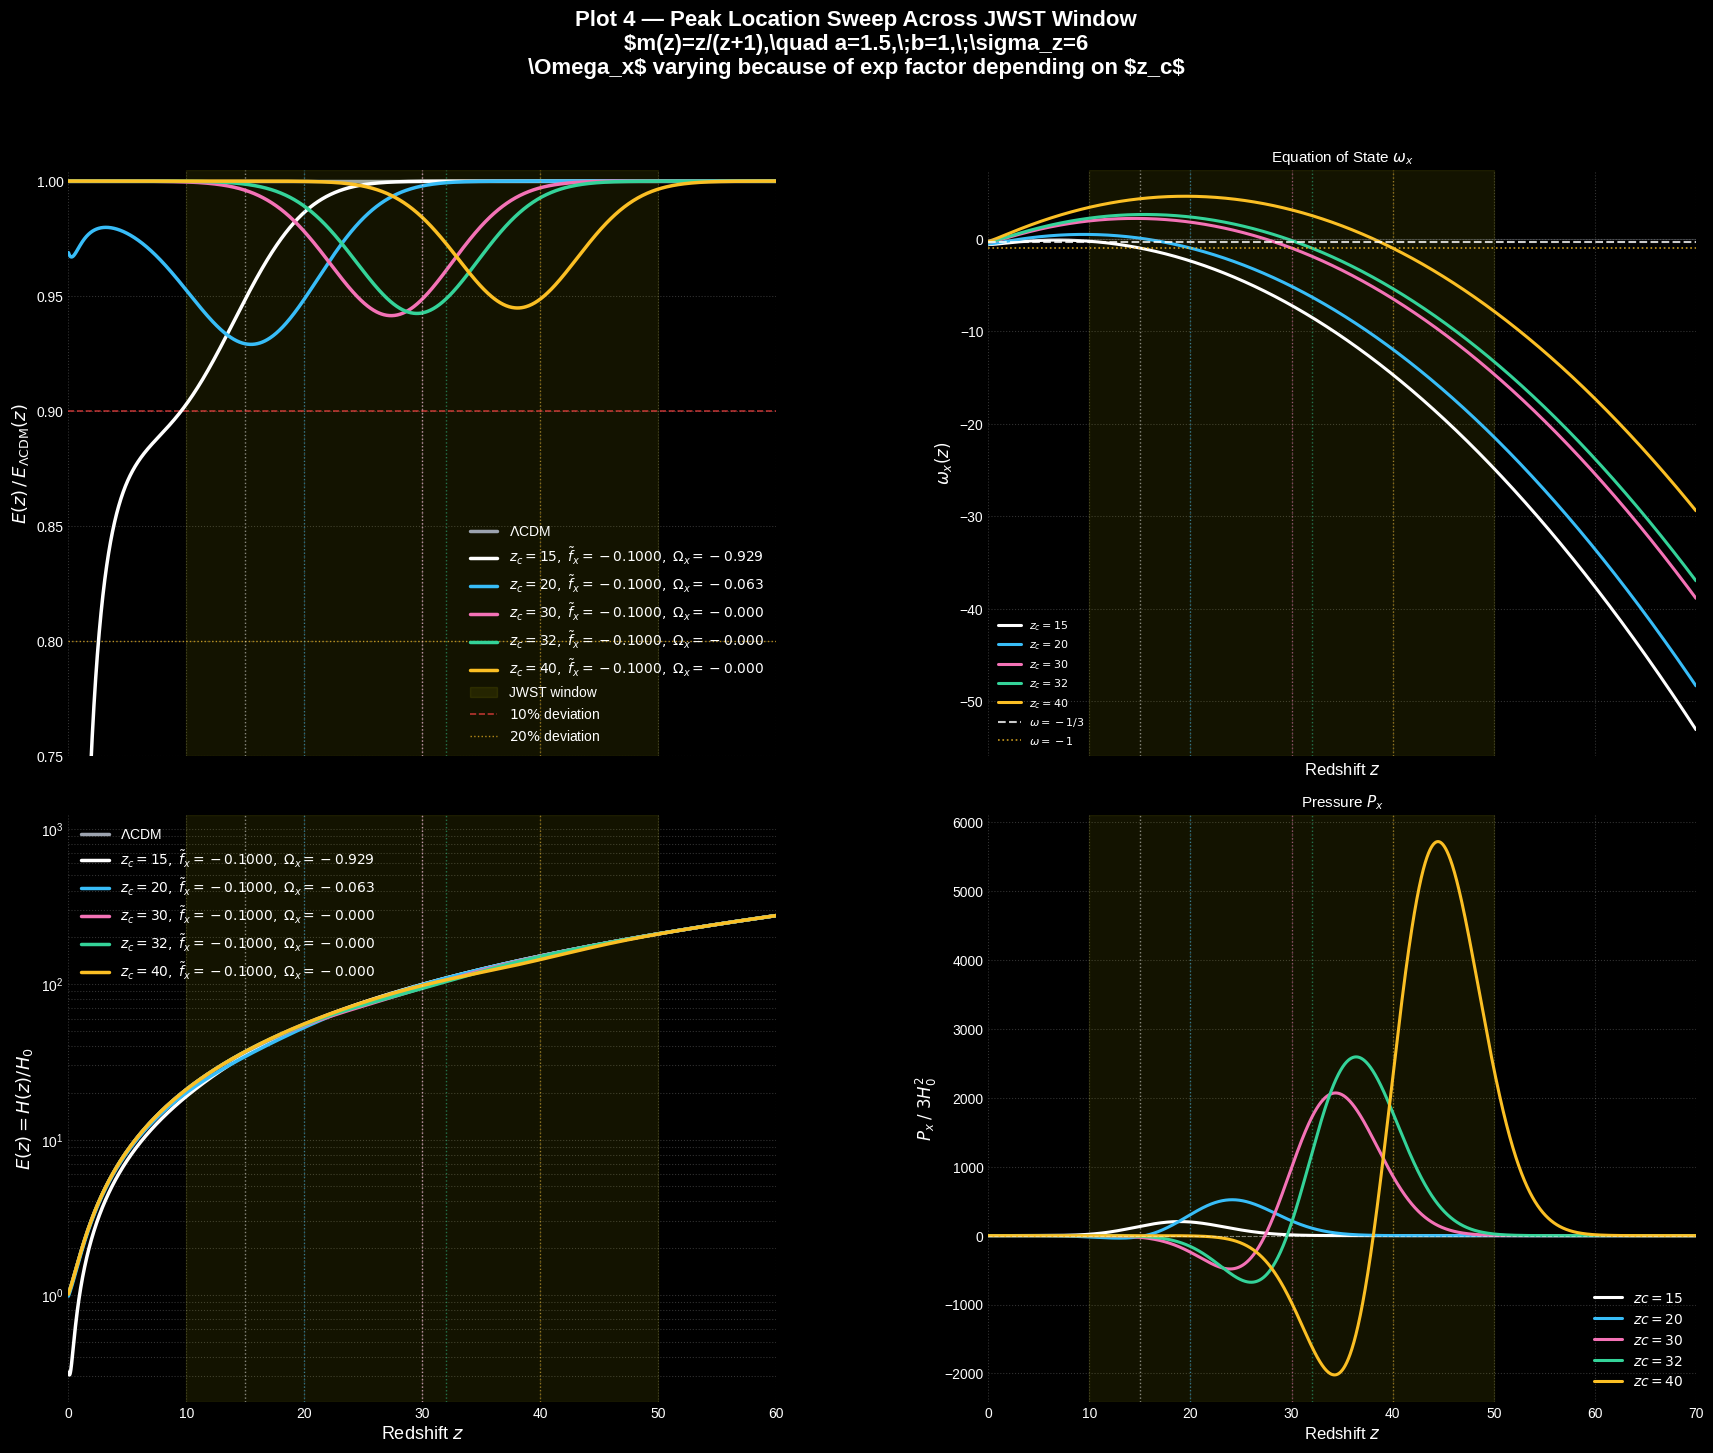

In [35]:

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — z_c Sweep: Targeting Any Epoch in the JWST Window
# a=1.5, b=1, sigma_z=6, Omega_x=-5e-3 | z_c sweep
# ═══════════════════════════════════════════════════════════════════════════════

A4, B4, SZ4 = 1.5, 1.0, 5
def Ox_from_fpeak(ftilde, a_val, b_val, zc, sz):
    """Given a desired signed f̃_x, back-calculate the required Omega_x."""
    Wpc  = calc_Wz_new(zc, a_val, b_val, zc, sz)   # W(z_c)
    Elc2 = Ez_lcdm(np.array([zc]))[0]**2            # E²_ΛCDM(z_c)
    return ftilde * Elc2 / Wpc

FTILDE_FIXED = -0.10
PARAMS_P4 = [
    dict(zc=15, Ox=Ox_from_fpeak(FTILDE_FIXED, A4, B4, 15, SZ4),label=r"$z_c = 15$"),
    dict(zc=20, Ox=Ox_from_fpeak(FTILDE_FIXED, A4, B4, 20, SZ4),label=r"$z_c = 20$"),
    dict(zc=30, Ox=Ox_from_fpeak(FTILDE_FIXED, A4, B4, 30, SZ4),label=r"$z_c = 30$"),
    dict(zc=32, Ox=Ox_from_fpeak(FTILDE_FIXED, A4, B4, 32, SZ4),label=r"$z_c = 32$"),
    dict(zc=40, Ox=Ox_from_fpeak(FTILDE_FIXED, A4, B4, 40, SZ4),label=r"$z_c = 40$"),
]
COLORS_P4 = [
    '#ffffff', # 1. Pure White (Best for a baseline/reference)
    '#38bdf8', # 2. Sky Blue
    '#f472b6', # 3. Hot Pink
    '#34d399', # 4. Emerald Green
    '#fbbf24', # 5. Amber/Yellow
    '#a78bfa', # 6. Soft Purple
    '#f87171', # 7. Coral Red
    '#22d3ee', # 8. Cyan
    '#fb923c', # 9. Orange
    '#818cf8', # 10. Indigo
    '#a3e635', # 11. Lime
    '#f472b6', # 12. Rose
    '#2dd4bf', # 13. Teal
    '#e879f9', # 14. Fuchsia
    '#94a3b8'  # 15. Slate/Silver
]

fig, axes = plt.subplots(2, 2, figsize=(21, 16), sharex='col')
fig.subplots_adjust(hspace=0.1, wspace=0.3)

ax_top, ax_omx = axes[0]   # left=ratio,   right=omega_x
ax_bot, ax_Px  = axes[1]   # left=raw E(z), right=P_x


fig.suptitle(
    r"Plot 4 — Peak Location Sweep Across JWST Window""\n"
    r"$m(z)=z/(z+1),\quad a=1.5,\;b=1,\;\sigma_z=6""\n"
    r"\Omega_x$ varying because of exp factor depending on $z_c$",
    fontsize=16, fontweight='bold', y=0.98)


ax_top.axhline(1.0, color='#9ca3af', lw=2.5, ls='-', label=r'$\Lambda$CDM', zorder=1)
ax_bot.plot(z_arr, El_arr, color='#9ca3af', lw=2.5, label=r'$\Lambda$CDM', zorder=1)

for p, c in zip(PARAMS_P4, COLORS_P4):
    fp   = get_fpeak_new(p['Ox'], A4, B4, p['zc'], SZ4)
    lbl = p["label"] + rf"$,\;\tilde{{f}}_x = {fp:.4f}$" + rf"$, \; \Omega_x = {p['Ox']:.3f}$"
    Ez_m = get_Ez_new(z_arr, p['Ox'], A4, B4, p["zc"], SZ4)
    ax_top.plot(z_arr, Ez_m / El_arr, color=c, lw=2.5, label=lbl, zorder=2)
    ax_bot.plot(z_arr, Ez_m,          color=c, lw=2.5, label=lbl, zorder=2)
    # Mark each z_c
    for ax in [ax_top, ax_bot, ax_omx, ax_Px]:
        ax.axvline(p["zc"], color=c, lw=1.0, ls=':', alpha=0.5)

for ax in [ax_top, ax_bot]:
    ax.axvspan(10, 50, alpha=0.08, color='yellow', label='JWST window' if ax is ax_top else '')
    ax.axvline(ZC1, color='white', lw=1.0, ls=':', alpha=0.4)
    ax.set_xlim(0, 70)
    ax.grid(True, which='both', ls=':', alpha=0.2)
    ax.legend(fontsize=10, framealpha=0.6, loc='upper left')

ax_top.set_ylim(0.965, 1.005)
ax_top.set_ylabel(r'$E(z)\,/\,E_{\Lambda\mathrm{CDM}}(z)$', fontsize=13)
ax_top.tick_params(labelbottom=False)

ax_bot.set_yscale('log')
ax_bot.set_ylabel(r'$E(z) = H(z)/H_0$', fontsize=13)
ax_bot.set_xlabel(r'Redshift $z$', fontsize=13)



plot_omega_x(ax_omx, z_plot, PARAMS_P4, COLORS_P4, A4, B4, SZ4,
             model='new', sweep_key='zc')        # ← change to match cell

plot_Px(ax_Px, z_plot, PARAMS_P4, COLORS_P4, A4, B4, SZ4,
        model='new', sweep_key='zc')             # ← change to match cell

ax_omx.set_xlim(0, 70)
ax_Px.set_xlim(0, 70)



plt.savefig("Plot4_zc_sweep.png", dpi=150, bbox_inches='tight')

ax_top.set_ylim(0.75, 1.005)
ax_top.set_xlim(0,60)
ax_top.axhline(0.90, color='#ff4444', lw=1.2, ls='--', alpha=0.7, label=r'$10\%$ deviation', zorder=1)
ax_top.axhline(0.80, color='#fbbf24', lw=1.0, ls=':',  alpha=0.7, label=r'$20\%$ deviation', zorder=1)
ax_top.legend(loc='lower right')
plt.legend(loc='lower right')
plt.savefig("Plot4_zc_sweep.png", dpi=200, bbox_inches='tight')

plt.show()


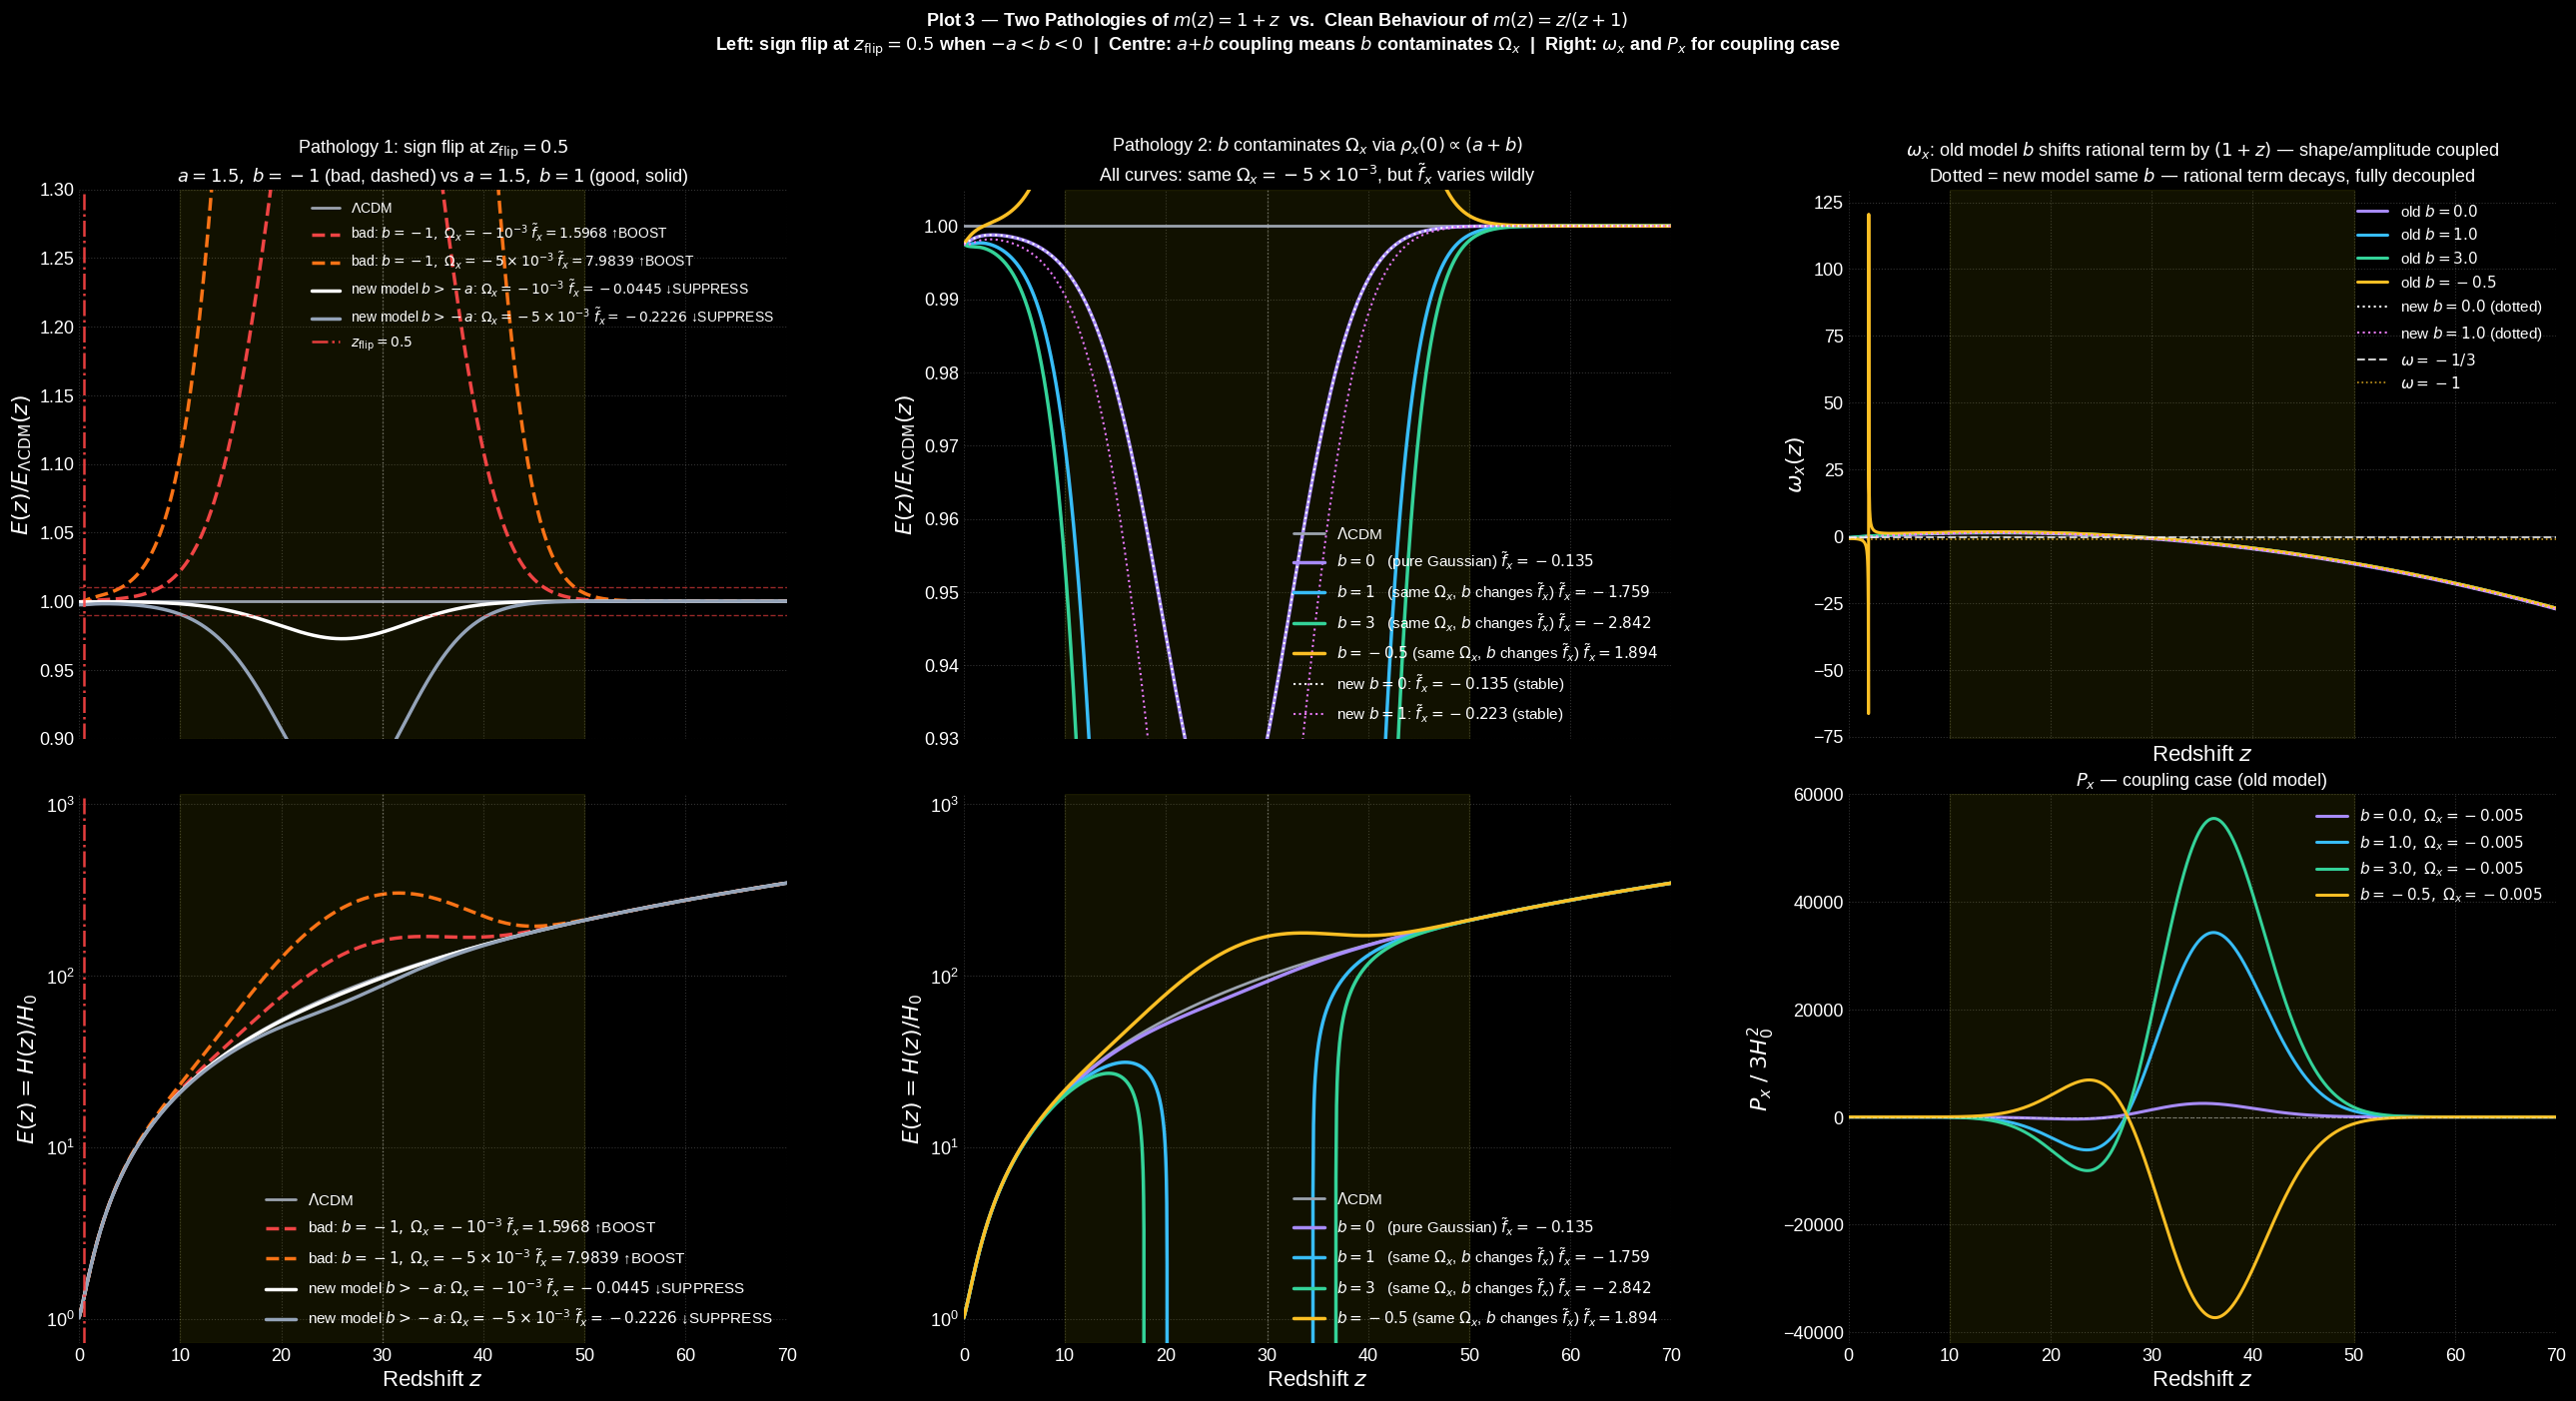

In [36]:
# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Two Pathologies of m(z) = (1+z)
# ═══════════════════════════════════════════════════════════════════════════════

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ── Rebuild old model lambdified functions (self-contained) ───────────────────
_z, _H0 = sp.symbols('z H_0', positive=True)
_Or, _Om, _Ol, _Ox = sp.symbols('Omega_r Omega_m Omega_lambda Omega_x', real=True)
_a, _b, _zc, _sz   = sp.symbols('a b z_c sigma_z', real=True)

_Wz_old = (
    (_a + _b*(1+_z)) / (_a + _b)
    * sp.exp((_zc**2 - (_z - _zc)**2) / (2*_sz**2))
)
_Hz2_old = _H0**2 * (
    _Om*(1+_z)**3 + _Or*(1+_z)**4 + _Ol + _Ox*_Wz_old
)
_calc_Hz2_old = sp.lambdify(
    (_z, _H0, _Or, _Om, _Ol, _Ox, _a, _b, _zc, _sz), _Hz2_old, 'numpy')
_calc_Wz_old  = sp.lambdify(
    (_z, _a, _b, _zc, _sz), _Wz_old, 'numpy')

def get_Ez_old(z_arr, Ox, a_val, b_val, zc, sz):
    Hz2 = _calc_Hz2_old(z_arr, H0, OR, OM, OL, Ox, a_val, b_val, zc, sz)
    return np.sqrt(np.maximum(Hz2, 0.0)) / H0

def fpeak_old(Ox, a_val, b_val, zc, sz):
    Wp = _calc_Wz_old(zc, a_val, b_val, zc, sz)
    return Ox * Wp / Ez_lcdm(np.array([zc]))[0]**2

# ── Fixed parameters ──────────────────────────────────────────────────────────
ZC3, SZ3 = 30, 6
OX_BASE  = -5e-3

# ── PATHOLOGY 1 ───────────────────────────────────────────────────────────────
A_BAD, B_BAD = 1.5, -1.0
z_flip = (A_BAD + B_BAD) / abs(B_BAD)   # = 0.5

PARAMS_BAD = [
    dict(Ox=-1e-3, label=r"bad: $b=-1,\;\Omega_x=-10^{-3}$"),
    dict(Ox=-5e-3, label=r"bad: $b=-1,\;\Omega_x=-5\times10^{-3}$"),
]

# ── PATHOLOGY 2 ───────────────────────────────────────────────────────────────
A_COUP = 1.5
PARAMS_COUPLING = [
    dict(b= 0.0, Ox=OX_BASE, label=r"$b=0$   (pure Gaussian)"),
    dict(b= 1.0, Ox=OX_BASE, label=r"$b=1$   (same $\Omega_x$, $b$ changes $\tilde{f}_x$)"),
    dict(b= 3.0, Ox=OX_BASE, label=r"$b=3$   (same $\Omega_x$, $b$ changes $\tilde{f}_x$)"),
    dict(b=-0.5, Ox=OX_BASE, label=r"$b=-0.5$ (same $\Omega_x$, $b$ changes $\tilde{f}_x$)"),
]

# ── Good reference ────────────────────────────────────────────────────────────
PARAMS_GOOD = [
    dict(Ox=-1e-3, label=r"new model $b>-a$: $\Omega_x=-10^{-3}$"),
    dict(Ox=-5e-3, label=r"new model $b>-a$: $\Omega_x=-5\times10^{-3}$"),
]
A_GOOD, B_GOOD = 1.5, 1.0

COLORS_BAD      = ['#ef4444', '#f97316']
COLORS_COUPLING = ['#a78bfa', '#38bdf8', '#34d399', '#fbbf24']
COLORS_GOOD     = ['#ffffff', '#94a3b8']

# ── z arrays ──────────────────────────────────────────────────────────────────
z_arr  = np.logspace(-5, np.log10(125), 10000)
z_plot = np.linspace(1e-3, 70, 3000)
El_arr = Ez_lcdm(z_arr)

# ── Font sizes ────────────────────────────────────────────────────────────────
FS_LABEL  = 16    # axis labels
FS_TICK   = 13    # tick labels
FS_LEG    = 11    # legend text
FS_TITLE  = 13    # subplot titles

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(32, 15))
fig.subplots_adjust(hspace=0.1, wspace=0.25)

ax_flip_top, ax_coup_top, ax_omx = axes[0]
ax_flip_bot, ax_coup_bot, ax_Px  = axes[1]

fig.suptitle(
    r"Plot 3 — Two Pathologies of $m(z)=1+z$  vs.  Clean Behaviour of $m(z)=z/(z+1)$""\n"
    r"Left: sign flip at $z_{\rm flip}=0.5$ when $-a<b<0$  |  "
    r"Centre: $a{+}b$ coupling means $b$ contaminates $\Omega_x$  |  "
    r"Right: $\omega_x$ and $P_x$ for coupling case",
    fontsize=13, fontweight='bold', y=1.00)

# ── apply tick fontsize globally ──────────────────────────────────────────────
for ax in axes.flat:
    ax.tick_params(labelsize=FS_TICK)

# ─────────────────────────────────────────────────────────────────────────────
# COLUMN 0 — Sign flip
# ─────────────────────────────────────────────────────────────────────────────
ax_flip_top.set_title(
    r"Pathology 1: sign flip at $z_{\rm flip}=0.5$""\n"
    r"$a=1.5,\;b=-1$ (bad, dashed) vs $a=1.5,\;b=1$ (good, solid)",
    fontsize=FS_TITLE)

ax_flip_top.axhline(1.0, color='#9ca3af', lw=2, ls='-', label=r'$\Lambda$CDM')
ax_flip_bot.plot(z_arr, El_arr, color='#9ca3af', lw=2, label=r'$\Lambda$CDM')

for p, c in zip(PARAMS_BAD, COLORS_BAD):
    fp   = fpeak_old(p["Ox"], A_BAD, B_BAD, ZC3, SZ3)
    lbl  = p["label"] + rf"$\;\tilde{{f}}_x={fp:.4f}$ ↑BOOST"
    Ez_m = get_Ez_old(z_arr, p["Ox"], A_BAD, B_BAD, ZC3, SZ3)
    ax_flip_top.plot(z_arr, Ez_m/El_arr, color=c, lw=2.5, ls='--', label=lbl)
    ax_flip_bot.plot(z_arr, Ez_m,        color=c, lw=2.5, ls='--', label=lbl)

for p, c in zip(PARAMS_GOOD, COLORS_GOOD):
    fp   = get_fpeak_new(p["Ox"], A_GOOD, B_GOOD, ZC3, SZ3)
    lbl  = p["label"] + rf"$\;\tilde{{f}}_x={fp:.4f}$ ↓SUPPRESS"
    Ez_m = get_Ez_new(z_arr, p["Ox"], A_GOOD, B_GOOD, ZC3, SZ3)
    ax_flip_top.plot(z_arr, Ez_m/El_arr, color=c, lw=2.5, ls='-', label=lbl)
    ax_flip_bot.plot(z_arr, Ez_m,        color=c, lw=2.5, ls='-', label=lbl)

for ax in [ax_flip_top, ax_flip_bot]:
    ax.axvline(z_flip, color='#ff4444', lw=1.8, ls='-.', alpha=0.9,
               label=rf'$z_{{\rm flip}}={z_flip}$' if ax is ax_flip_top else '')
    ax.axvline(ZC3, color='white', lw=1.0, ls=':', alpha=0.35)
    ax.axvspan(10, 50, alpha=0.07, color='yellow')
    ax.set_xlim(0, 70)
    ax.grid(True, ls=':', alpha=0.2)
    ax.legend(fontsize=FS_LEG, framealpha=0.55, loc='lower right')

ax_flip_top.set_ylim(0.9, 1.3)
ax_flip_top.legend(loc='upper right')
ax_flip_top.axhline(0.99, color='#ff4444', lw=1, ls='--', alpha=0.6)
ax_flip_top.axhline(1.01, color='#ff4444', lw=1, ls='--', alpha=0.6)
ax_flip_top.set_ylabel(r'$E(z)/E_{\Lambda\rm CDM}(z)$', fontsize=FS_LABEL)
ax_flip_top.tick_params(labelbottom=False)
ax_flip_bot.set_yscale('log')
ax_flip_bot.set_ylabel(r'$E(z)=H(z)/H_0$', fontsize=FS_LABEL)
ax_flip_bot.set_xlabel(r'Redshift $z$',     fontsize=FS_LABEL)

# ─────────────────────────────────────────────────────────────────────────────
# COLUMN 1 — a+b coupling   ← legends BOTTOM RIGHT
# ─────────────────────────────────────────────────────────────────────────────
ax_coup_top.set_title(
    r"Pathology 2: $b$ contaminates $\Omega_x$ via $\rho_x(0)\propto(a+b)$""\n"
    r"All curves: same $\Omega_x=-5\times10^{-3}$, but $\tilde{f}_x$ varies wildly",
    fontsize=FS_TITLE)

ax_coup_top.axhline(1.0, color='#9ca3af', lw=2, ls='-', label=r'$\Lambda$CDM')
ax_coup_bot.plot(z_arr, El_arr, color='#9ca3af', lw=2, label=r'$\Lambda$CDM')

for p, c in zip(PARAMS_COUPLING, COLORS_COUPLING):
    b_val = p['b']
    fp    = fpeak_old(p["Ox"], A_COUP, b_val, ZC3, SZ3)
    lbl   = p["label"] + rf"$\;\tilde{{f}}_x={fp:.3f}$"
    Ez_m  = get_Ez_old(z_arr, p["Ox"], A_COUP, b_val, ZC3, SZ3)
    ax_coup_top.plot(z_arr, Ez_m/El_arr, color=c, lw=2.5, label=lbl)
    ax_coup_bot.plot(z_arr, Ez_m,        color=c, lw=2.5, label=lbl)

fp_new_b0  = get_fpeak_new(OX_BASE, A_GOOD, 0.0, ZC3, SZ3)
fp_new_b1  = get_fpeak_new(OX_BASE, A_GOOD, 1.0, ZC3, SZ3)
Ez_new_b0  = get_Ez_new(z_arr, OX_BASE, A_GOOD, 0.0, ZC3, SZ3)
Ez_new_b1  = get_Ez_new(z_arr, OX_BASE, A_GOOD, 1.0, ZC3, SZ3)
ax_coup_top.plot(z_arr, Ez_new_b0/El_arr, color='white',   lw=1.5, ls=':',
                 label=rf"new $b=0$: $\tilde{{f}}_x={fp_new_b0:.3f}$ (stable)")
ax_coup_top.plot(z_arr, Ez_new_b1/El_arr, color='#e879f9', lw=1.5, ls=':',
                 label=rf"new $b=1$: $\tilde{{f}}_x={fp_new_b1:.3f}$ (stable)")

for ax in [ax_coup_top, ax_coup_bot]:
    ax.axvline(ZC3, color='white', lw=1.0, ls=':', alpha=0.35)
    ax.axvspan(10, 50, alpha=0.07, color='yellow')
    ax.set_xlim(0, 70)
    ax.grid(True, ls=':', alpha=0.2)
    ax.legend(fontsize=FS_LEG, framealpha=0.55, loc='lower right')   # ← BOTTOM RIGHT

ax_coup_top.set_ylim(0.93, 1.005)
ax_coup_top.set_ylabel(r'$E(z)/E_{\Lambda\rm CDM}(z)$', fontsize=FS_LABEL)
ax_coup_top.tick_params(labelbottom=False)
ax_coup_bot.set_yscale('log')
ax_coup_bot.set_ylabel(r'$E(z)=H(z)/H_0$', fontsize=FS_LABEL)
ax_coup_bot.set_xlabel(r'Redshift $z$',     fontsize=FS_LABEL)

# ─────────────────────────────────────────────────────────────────────────────
# COLUMN 2 — omega_x and P_x
# ─────────────────────────────────────────────────────────────────────────────
ax_omx.set_title(
    r"$\omega_x$: old model $b$ shifts rational term by $(1+z)$ — shape/amplitude coupled""\n"
    r"Dotted = new model same $b$ — rational term decays, fully decoupled",
    fontsize=FS_TITLE)

for p, c in zip(PARAMS_COUPLING, COLORS_COUPLING):
    b_val = p['b']
    wx    = calc_omega_x(z_plot, A_COUP, b_val, ZC3, SZ3, model='old')
    ax_omx.plot(z_plot, wx, color=c, lw=2.2, label=rf"old $b={b_val}$")

for b_val, c in [(0.0, 'white'), (1.0, '#e879f9')]:
    wx_new = calc_omega_x(z_plot, A_GOOD, b_val, ZC3, SZ3, model='new')
    ax_omx.plot(z_plot, wx_new, color=c, lw=1.5, ls=':',
                label=rf"new $b={b_val}$ (dotted)")

ax_omx.axhline(-1/3, color='white',   lw=1.5, ls='--', alpha=0.8, label=r'$\omega=-1/3$')
ax_omx.axhline(-1,   color='#fbbf24', lw=1.2, ls=':',  alpha=0.8, label=r'$\omega=-1$')
ax_omx.axhline(0,    color='#9ca3af', lw=0.8, ls='-',  alpha=0.3)
ax_omx.axvspan(10, 50, alpha=0.07, color='yellow')
ax_omx.set_xlim(0, 70)
ax_omx.set_ylabel(r'$\omega_x(z)$', fontsize=FS_LABEL)
ax_omx.set_xlabel(r'Redshift $z$',  fontsize=FS_LABEL)
ax_omx.set_title(ax_omx.get_title(), fontsize=FS_TITLE)
ax_omx.grid(True, ls=':', alpha=0.2)
ax_omx.legend(fontsize=FS_LEG, framealpha=0.55)
ax_omx.tick_params(labelbottom=False)

for p, c in zip(PARAMS_COUPLING, COLORS_COUPLING):
    b_val = p['b']
    Px    = calc_Px(z_plot, OX_BASE, A_COUP, b_val, ZC3, SZ3, model='old')
    ax_Px.plot(z_plot, Px, color=c, lw=2.2,
               label=rf"$b={b_val},\;\Omega_x={OX_BASE}$")

ax_Px.axhline(0, color='white', lw=0.8, ls='--', alpha=0.4)
ax_Px.axvspan(10, 50, alpha=0.07, color='yellow')
ax_Px.set_xlim(0, 70)
ax_Px.set_ylabel(r'$P_x\;/\;3H_0^2$', fontsize=FS_LABEL)
ax_Px.set_xlabel(r'Redshift $z$',      fontsize=FS_LABEL)
ax_Px.set_title(r'$P_x$ — coupling case (old model)', fontsize=FS_TITLE)
ax_Px.grid(True, ls=':', alpha=0.2)
ax_Px.legend(fontsize=FS_LEG, framealpha=0.55)   

plt.savefig("Plot5_oldmodel_pathologies.png", dpi=150, bbox_inches='tight')
plt.show()